#  Airline Passenger Satisfaction Prediction

# Problem Statement
### The airline industry operates in a highly competitive market where customer satisfaction directly impacts revenue, brand loyalty, and market share. Despite airlines investing significantly in cabin services, inflight amenities, and operational efficiency, they often lack a data-driven mechanism to identify which specific factors are driving passenger satisfaction or dissatisfaction.


# The core business problem is:
### Can we accurately predict whether an airline passenger will be Satisfied or Neutral/Dissatisfied based on their demographic profile, travel details, and service experience ratings — and identify the key drivers behind that outcome?

## DATA COLLECTION
### Dataset Source
### Platform: Kaggle

### Dataset Name: Airline Passenger Satisfaction

### Author: TJ Klein (modified from an earlier dataset by John D)

### Link: https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder,StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("airline_passenger_satisfaction.csv")
df = df.drop(columns=['Unnamed: 0', 'ID'], errors='ignore')

In [3]:
df.shape

(129880, 23)

#### This Dataset contains 23 columns and 1,29,880 rows

### COLUMN STRUCTURE

###  Demographics
- **Gender** → Passenger gender (Male/Female).  
  *Effect:* Often has little direct impact, but may interact with service preferences (e.g., seat comfort, food).  
- **Customer Type** → Loyal vs. disloyal customers.  
  *Effect:* Loyal customers are more likely to report satisfaction due to repeated positive experiences.  

- **Age** → Passenger age in years.  
  *Effect:* Older passengers may value comfort and service more, while younger passengers may prioritize convenience and speed.  



###  Travel Details
- **Type of Travel** → Business vs. Personal.  
  *Effect:* Business travelers usually expect higher service standards and punctuality, so delays or poor service can reduce satisfaction.  
- **Class** → Business, Eco, Eco Plus.  
  *Effect:* Higher classes (Business) generally correlate with higher satisfaction due to better amenities.  
- **Flight Distance** → Distance of the journey.  
  *Effect:* Longer flights amplify the importance of inflight services (wifi, entertainment, food, seat comfort).  



###  Service Ratings (0–5 scale)
- **Inflight WiFi Service** → Quality of internet onboard.  
  *Effect:* Strong predictor for satisfaction, especially for business travelers.  
- **Departure/Arrival Time Convenient** → Scheduling convenience.  
  *Effect:* Impacts satisfaction if flights align well with passenger needs.  
- **Ease of Online Booking** → Smoothness of booking process.  
  *Effect:* Poor booking experience can lower satisfaction before the flight even begins.  
- **Gate Location** → Accessibility of boarding gate.  
  *Effect:* Inconvenient gate locations reduce satisfaction.  
- **Food and Drink** → Quality of meals.  
  *Effect:* Strong influence on satisfaction, especially for long flights.  
- **Online Boarding** → Efficiency of boarding process.  
  *Effect:* Faster, smoother boarding increases satisfaction.  
- **Seat Comfort** → Comfort level of seats.  
  *Effect:* One of the strongest predictors of satisfaction.  
- **Inflight Entertainment** → Movies, music, etc.  
  *Effect:* Important for long flights; lack of entertainment reduces satisfaction.  
- **On-board Service** → General service quality.  
  *Effect:* Directly tied to satisfaction.  
- **Leg Room Service** → Space for legs.  
  *Effect:* Strong predictor; cramped seating lowers satisfaction.  
- **Baggage Handling** → Efficiency of baggage delivery.  
  *Effect:* Mishandled baggage strongly reduces satisfaction.  
- **Check-in Service** → Quality of check-in process.  
  *Effect:* Smooth check-in improves satisfaction.  
- **Inflight Service** → Overall service during flight.  
  *Effect:* Directly impacts satisfaction.  
- **Cleanliness** → Cabin cleanliness.  
  *Effect:* Strong influence; dirty cabins reduce satisfaction.  



###  Delays
- **Departure Delay in Minutes** → Delay at departure.  
  *Effect:* Longer delays reduce satisfaction significantly.  
- **Arrival Delay in Minutes** → Delay at arrival.  
  *Effect:* Strong negative impact on satisfaction, especially for business travelers.  



###  Target Variable
- **Satisfaction** → Binary outcome (Satisfied = 1, Neutral/Dissatisfied = 0).  
  *Effect:* Determined by the combined influence of demographics, travel details, service ratings, and delays.  

## Initial Data Inspection

In [4]:
df.head()

,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,Male,48,First-time,Business,Business,821,2,5.0,3,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,Female,35,Returning,Business,Business,821,26,39.0,2,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,Male,41,Returning,Business,Business,853,0,0.0,4,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,Male,50,Returning,Business,Business,1905,0,0.0,2,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,Female,49,Returning,Business,Business,3470,0,1.0,3,3,...,3,4,4,5,4,3,3,3,3,Satisfied


In [5]:
df.tail()

,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
129875,Male,28,Returning,Personal,Economy Plus,447,2,3.0,4,4,...,5,1,4,4,4,5,4,4,4,Neutral or Dissatisfied
129876,Male,41,Returning,Personal,Economy Plus,308,0,0.0,5,3,...,5,2,5,2,2,4,3,2,5,Neutral or Dissatisfied
129877,Male,42,Returning,Personal,Economy Plus,337,6,14.0,5,2,...,3,3,4,3,3,4,2,3,5,Neutral or Dissatisfied
129878,Male,50,Returning,Personal,Economy Plus,337,31,22.0,4,4,...,4,4,5,3,3,4,5,3,5,Satisfied
129879,Female,20,Returning,Personal,Economy Plus,337,0,0.0,1,3,...,4,2,4,2,2,2,3,2,1,Neutral or Dissatisfied


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 23 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   Gender                                  129880 non-null  object 
 1   Age                                     129880 non-null  int64  
 2   Customer Type                           129880 non-null  object 
 3   Type of Travel                          129880 non-null  object 
 4   Class                                   129880 non-null  object 
 5   Flight Distance                         129880 non-null  int64  
 6   Departure Delay                         129880 non-null  int64  
 7   Arrival Delay                           129487 non-null  float64
 8   Departure and Arrival Time Convenience  129880 non-null  int64  
 9   Ease of Online Booking                  129880 non-null  int64  
 10  Check-in Service                        1298

In [7]:
df.describe(include="all")

,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
count,129880,129880.000000,129880,129880,129880,129880.000000,129880.000000,129487.000000,129880.000000,129880.000000,...,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880
unique,2,NaN,2,2,3,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,Female,NaN,Returning,Business,Business,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Neutral or Dissatisfied
freq,65899,NaN,106100,89693,62160,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,73452
mean,NaN,39.427957,NaN,NaN,NaN,1190.316392,14.713713,15.091129,3.057599,2.756876,...,3.383023,3.441361,3.350878,3.286326,3.204774,3.642193,2.728696,3.358077,3.632114,NaN
std,NaN,15.119360,NaN,NaN,NaN,997.452477,38.071126,38.465650,1.526741,1.401740,...,1.287099,1.319289,1.316252,1.313682,1.329933,1.176669,1.329340,1.334049,1.180025,NaN
min,NaN,7.000000,NaN,NaN,NaN,31.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,NaN
25%,NaN,27.000000,NaN,NaN,NaN,414.000000,0.000000,0.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,2.000000,3.000000,NaN
50%,NaN,40.000000,NaN,NaN,NaN,844.000000,0.000000,0.000000,3.000000,3.000000,...,4.000000,4.000000,4.000000,3.000000,3.000000,4.000000,3.000000,4.000000,4.000000,NaN
75%,NaN,51.000000,NaN,NaN,NaN,1744.000000,12.000000,13.000000,4.000000,4.000000,...,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,5.000000,NaN


In [8]:
df.isna().sum()

Gender                                      0
Age                                         0
Customer Type                               0
Type of Travel                              0
Class                                       0
Flight Distance                             0
Departure Delay                             0
Arrival Delay                             393
Departure and Arrival Time Convenience      0
Ease of Online Booking                      0
Check-in Service                            0
Online Boarding                             0
Gate Location                               0
On-board Service                            0
Seat Comfort                                0
Leg Room Service                            0
Cleanliness                                 0
Food and Drink                              0
In-flight Service                           0
In-flight Wifi Service                      0
In-flight Entertainment                     0
Baggage Handling                  

##  Data Cleaning

In [9]:
df["Arrival Delay"] = df["Arrival Delay"].fillna(df["Arrival Delay"].median())

In [10]:
df.isna().sum()

Gender                                    0
Age                                       0
Customer Type                             0
Type of Travel                            0
Class                                     0
Flight Distance                           0
Departure Delay                           0
Arrival Delay                             0
Departure and Arrival Time Convenience    0
Ease of Online Booking                    0
Check-in Service                          0
Online Boarding                           0
Gate Location                             0
On-board Service                          0
Seat Comfort                              0
Leg Room Service                          0
Cleanliness                               0
Food and Drink                            0
In-flight Service                         0
In-flight Wifi Service                    0
In-flight Entertainment                   0
Baggage Handling                          0
Satisfaction                    

In [11]:
df.duplicated().sum()

np.int64(0)

### • Standardize column names

#### All Columns are standardized only not needed

### • Fix incorrect data types

#### All Datatypes are Correct

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 23 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   Gender                                  129880 non-null  object 
 1   Age                                     129880 non-null  int64  
 2   Customer Type                           129880 non-null  object 
 3   Type of Travel                          129880 non-null  object 
 4   Class                                   129880 non-null  object 
 5   Flight Distance                         129880 non-null  int64  
 6   Departure Delay                         129880 non-null  int64  
 7   Arrival Delay                           129880 non-null  float64
 8   Departure and Arrival Time Convenience  129880 non-null  int64  
 9   Ease of Online Booking                  129880 non-null  int64  
 10  Check-in Service                        1298

##   Exploratory Data Analysis (EDA)

### UNIVARIATE ANALYSIS

In [13]:
num_cols = df.select_dtypes("number").columns
num_cols

Index(['Age', 'Flight Distance', 'Departure Delay', 'Arrival Delay',
       'Departure and Arrival Time Convenience', 'Ease of Online Booking',
       'Check-in Service', 'Online Boarding', 'Gate Location',
       'On-board Service', 'Seat Comfort', 'Leg Room Service', 'Cleanliness',
       'Food and Drink', 'In-flight Service', 'In-flight Wifi Service',
       'In-flight Entertainment', 'Baggage Handling'],
      dtype='object')

In [14]:
cat_cols = df.select_dtypes("object").columns
cat_cols

Index(['Gender', 'Customer Type', 'Type of Travel', 'Class', 'Satisfaction'], dtype='object')

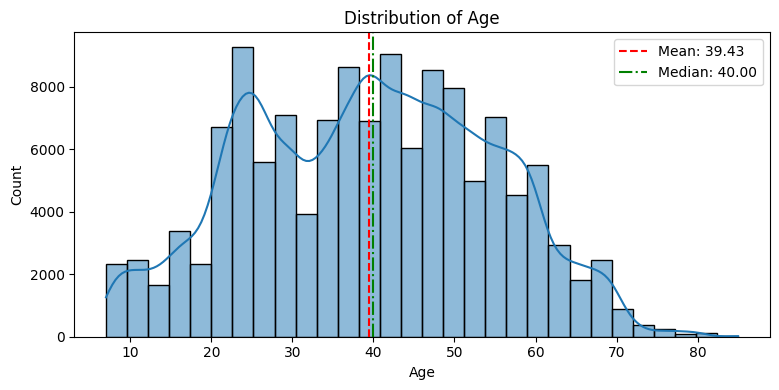

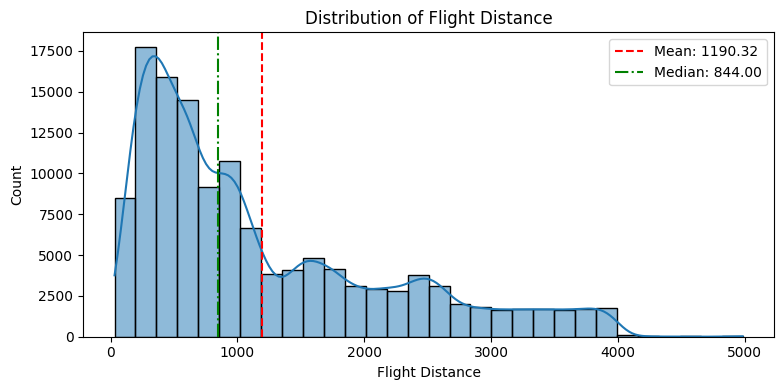

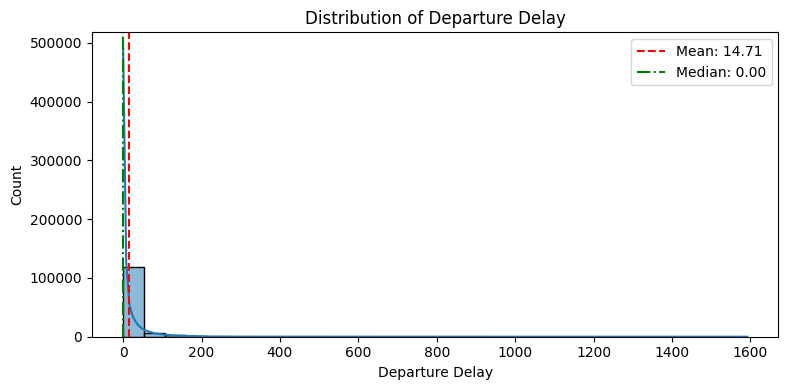

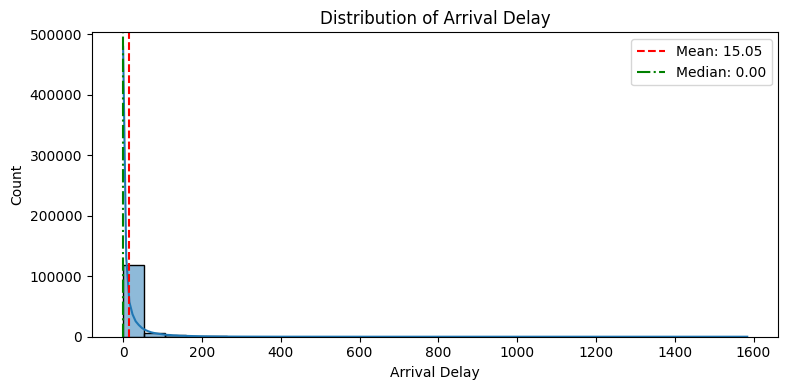

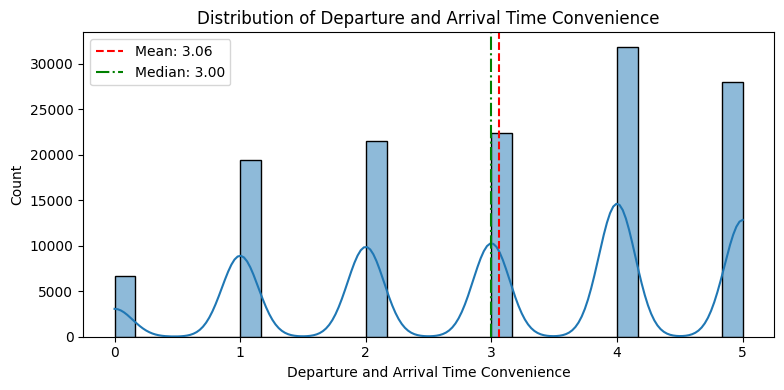

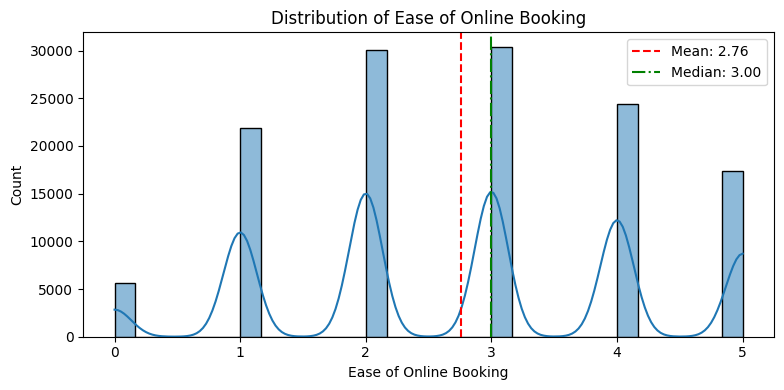

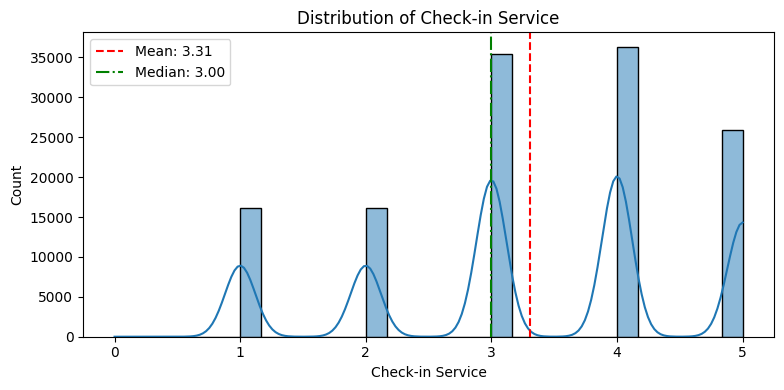

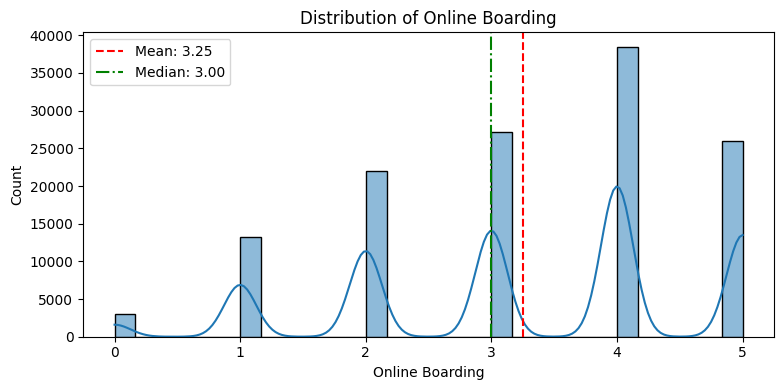

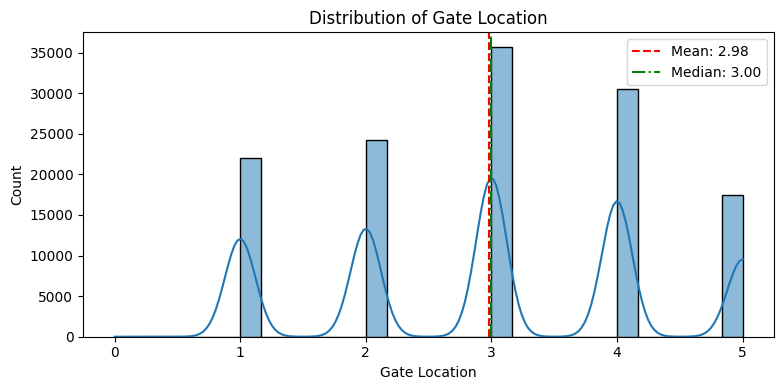

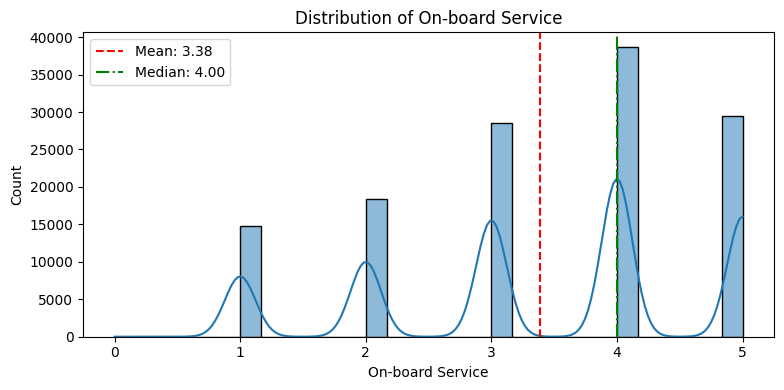

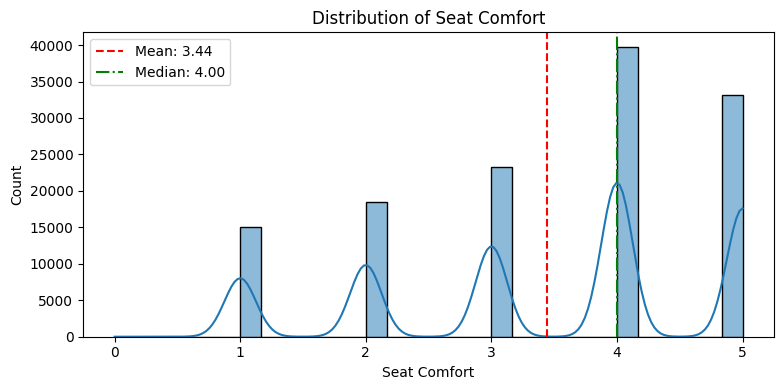

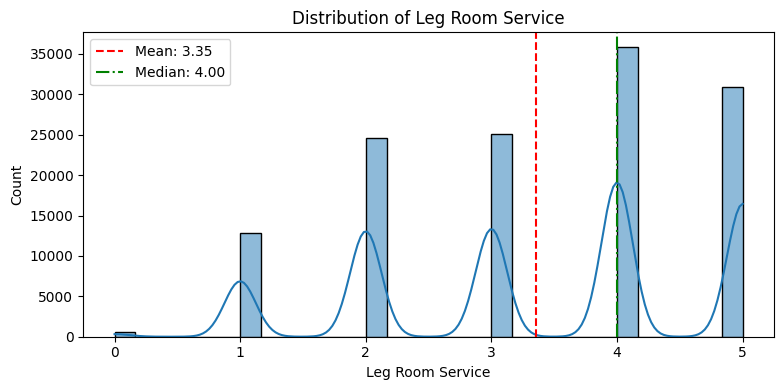

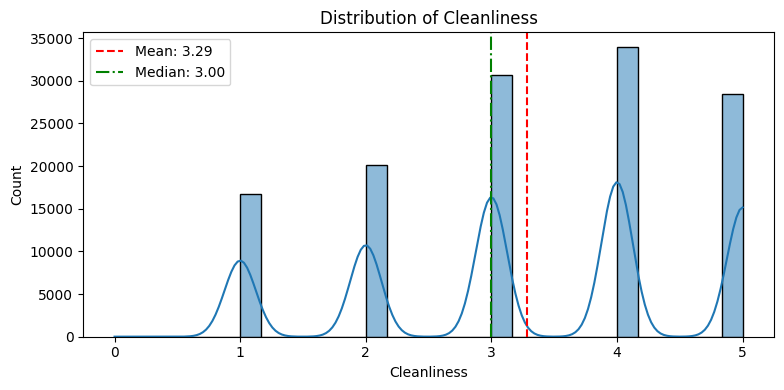

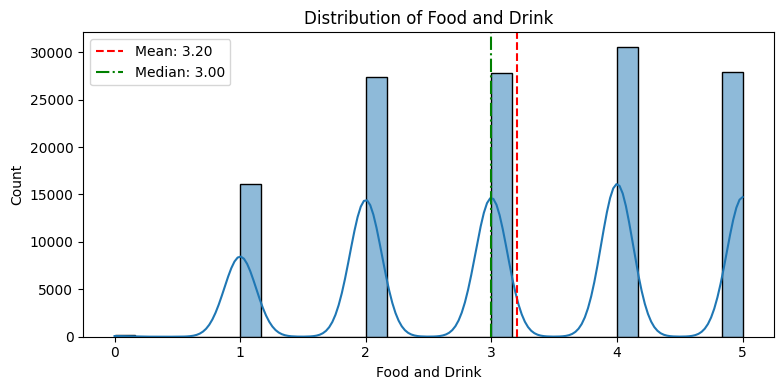

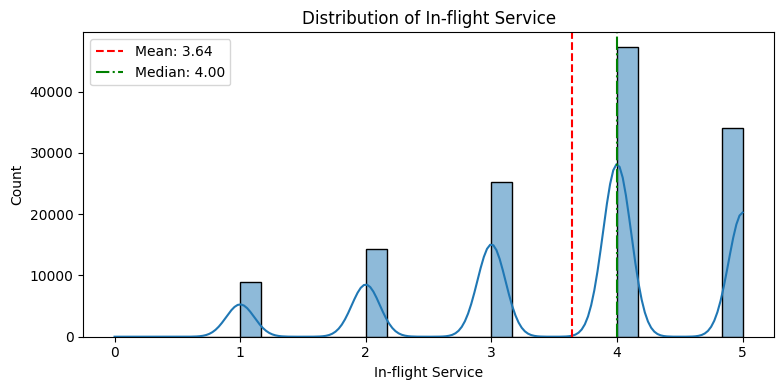

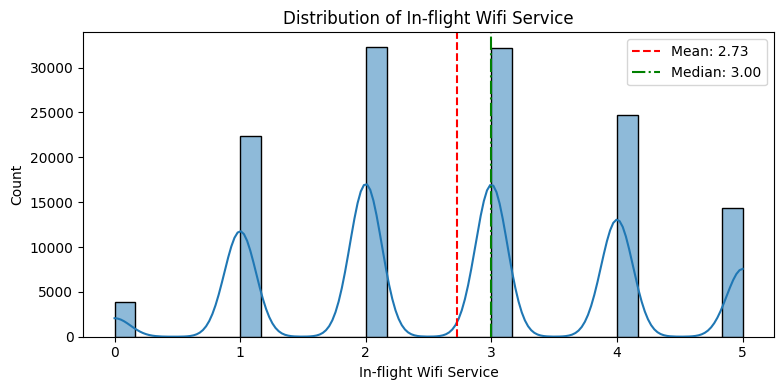

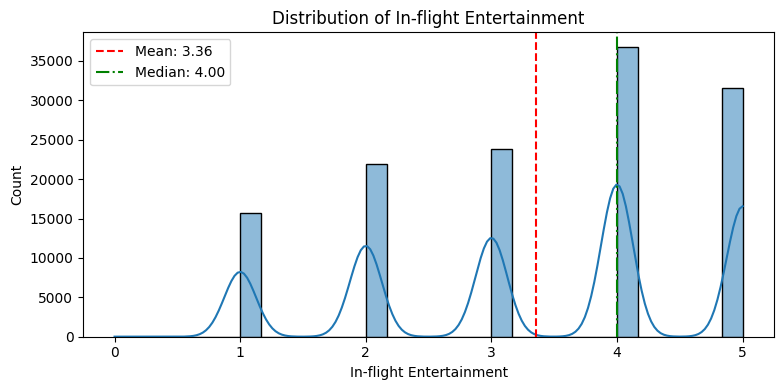

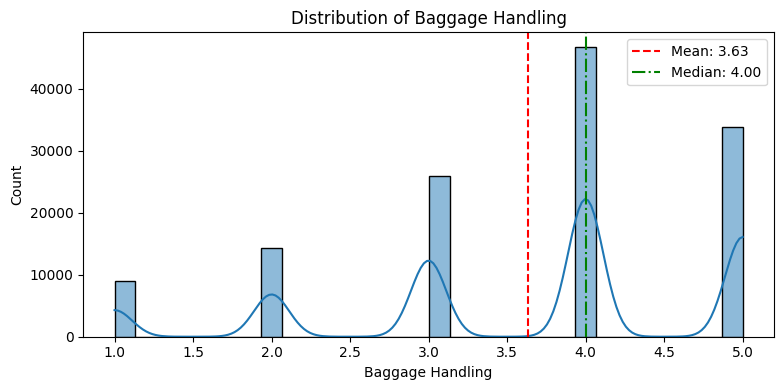

In [15]:
for col in num_cols:
    plt.figure(figsize=(15,4))

    plt.subplot(1,2,1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.axvline(df[col].mean(), color="red", linestyle="--", label=f"Mean: {df[col].mean():.2f}")
    plt.axvline(df[col].median(), color="green", linestyle="-.", label=f"Median: {df[col].median():.2f}")

    plt.title(f"Distribution of {col}")
    plt.legend()
    plt.tight_layout()
    plt.show()

### INSIGHITS
##  Distribution Analysis (Univariate)
- **Age** → Mean ≈ 39.4, Median ≈ 40. Distribution is fairly balanced, showing middle‑aged passengers dominate.  
- **Flight Distance** → Mean ≈ 1190 km, Median ≈ 844 km. Most flights are short to medium haul, with fewer long‑distance journeys.  
- **Service Ratings (0–5)** → Most features (wifi, booking, gate location, food, seat comfort, entertainment, service, cleanliness) cluster around 3–4, indicating average satisfaction.  
- **Delays** → Departure and arrival delays have median = 0, but mean ≈ 15 minutes, showing skewed distribution with many flights on time but some extreme delays.  

**Insight:** Most passengers rate services moderately, but delays and seat comfort are critical pain points.


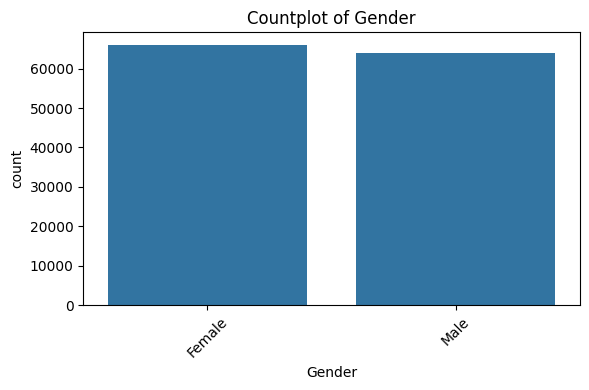

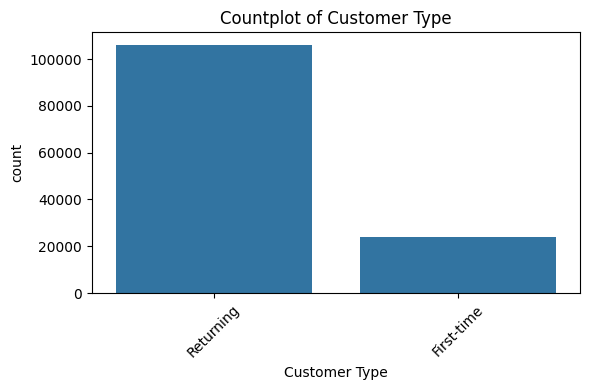

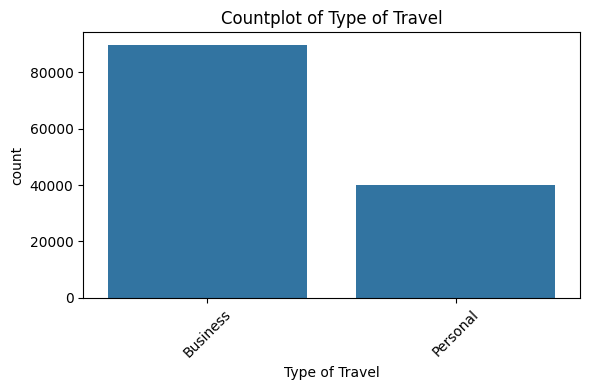

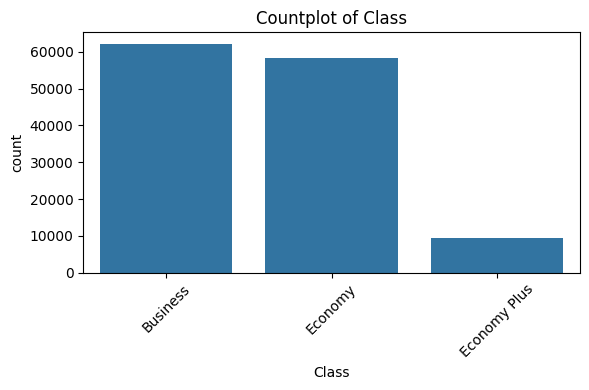

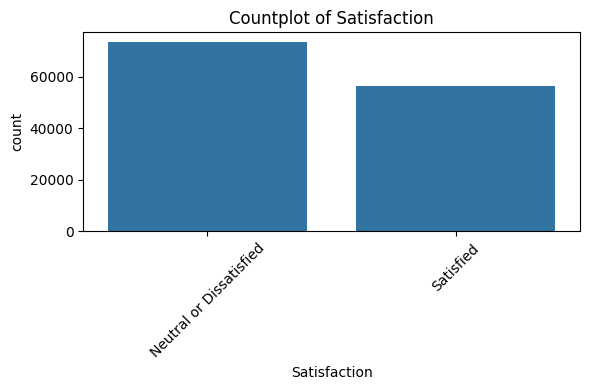

In [21]:
for col in cat_cols:
    plt.figure(figsize=(6,4))

    sns.countplot(x=df[col], order=df[col].value_counts().index)
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

### INSIGHITS


##  Categorical Distribution
- **Gender** → Balanced split between male and female.  
- **Customer Type** → Majority are loyal customers.  
- **Type of Travel** → Business travel dominates over personal travel.  
- **Class** → Economy class has the highest share, followed by Business and Eco Plus.  
- **Satisfaction** → Slightly more passengers are neutral/dissatisfied compared to satisfied.  

**Insight:** Loyal, business‑class travelers are more satisfied, while economy passengers show higher dissatisfaction.



## BI-VARIATE ANALYSIS

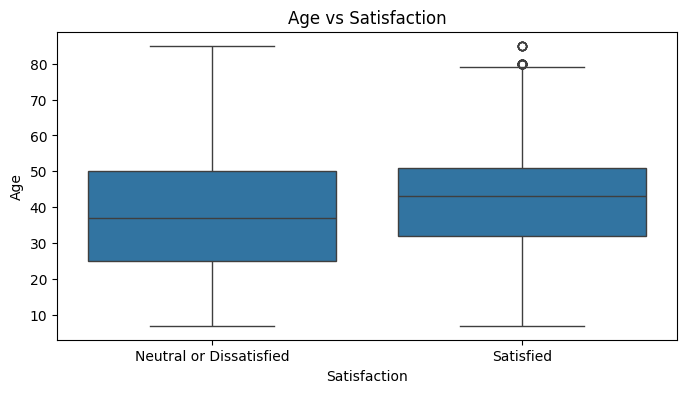

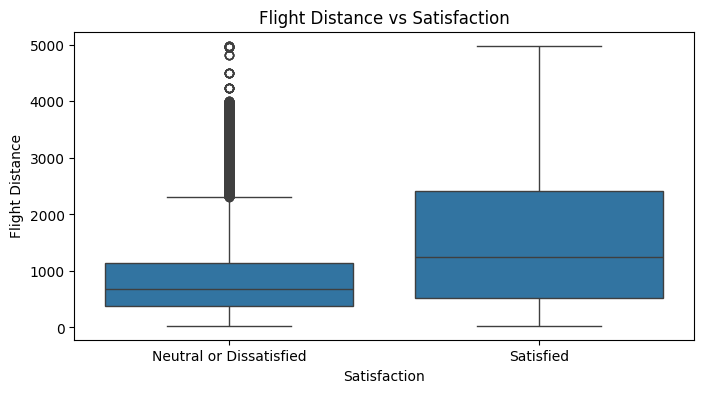

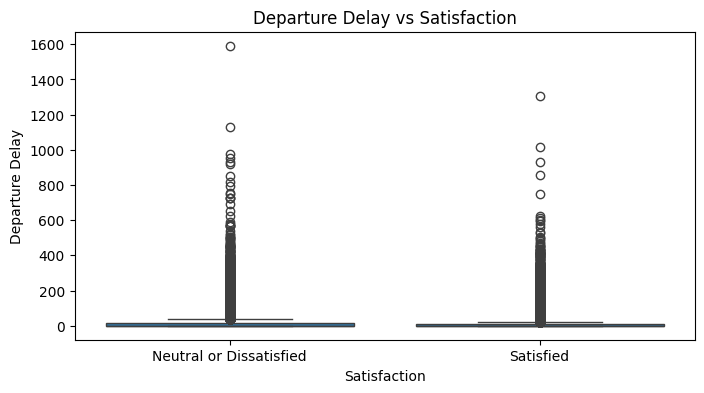

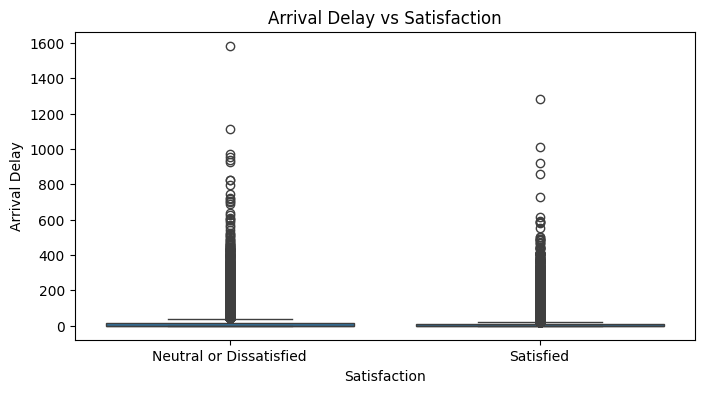

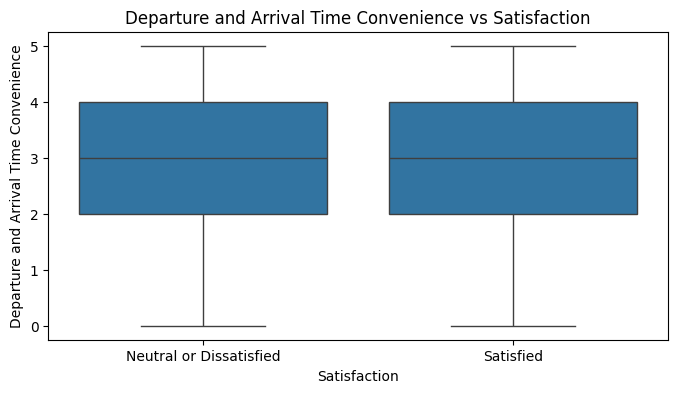

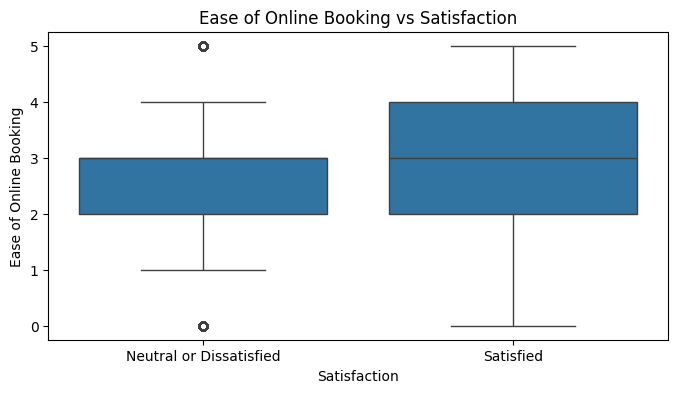

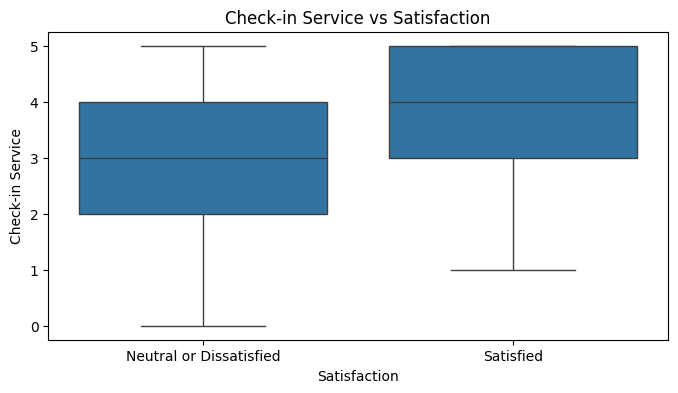

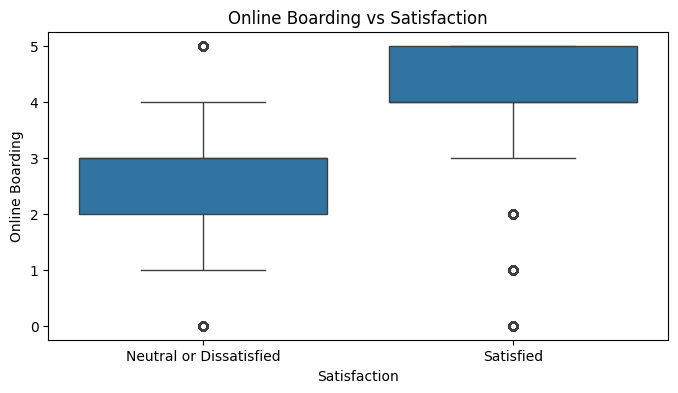

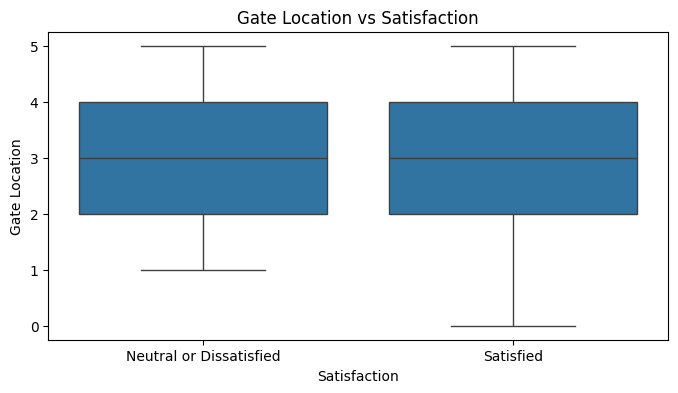

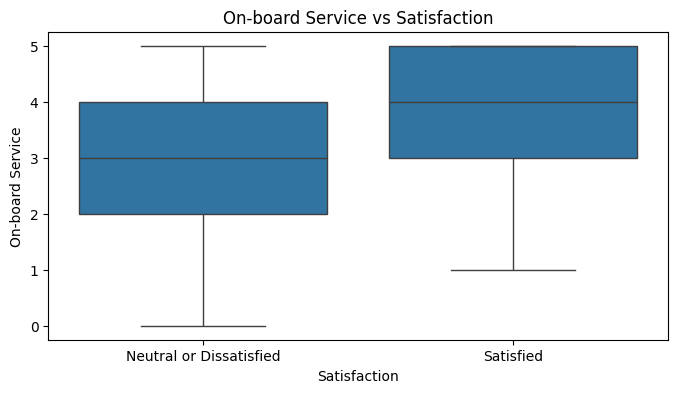

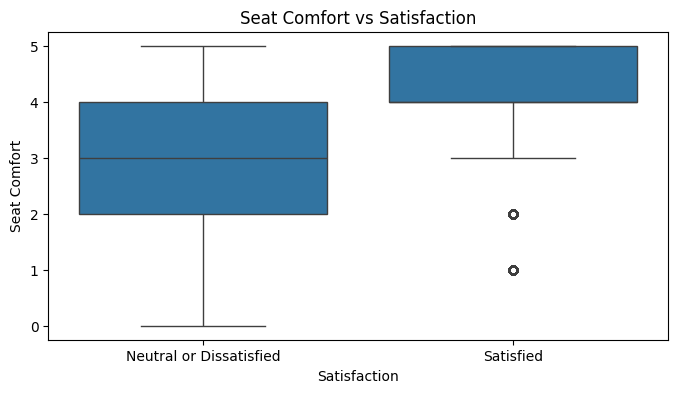

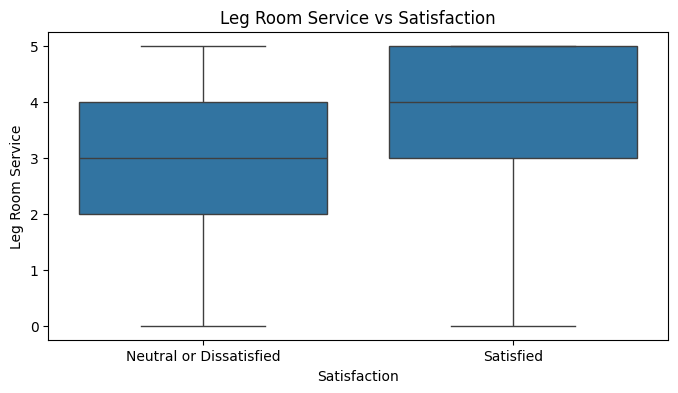

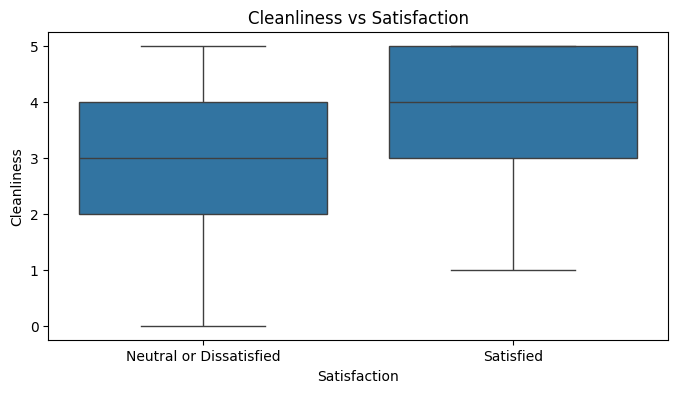

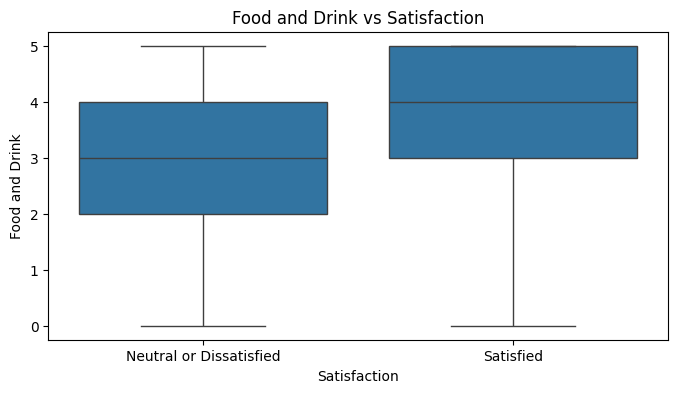

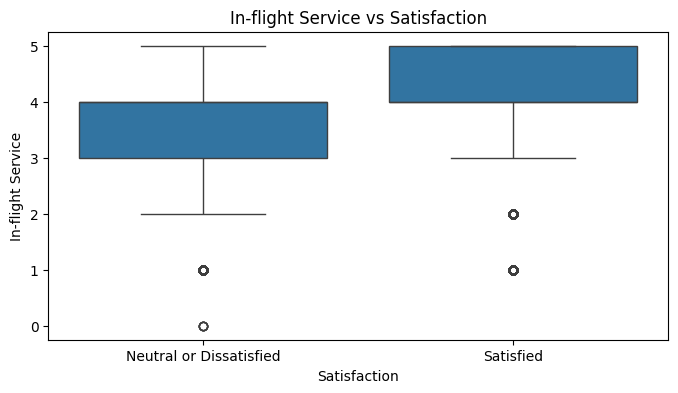

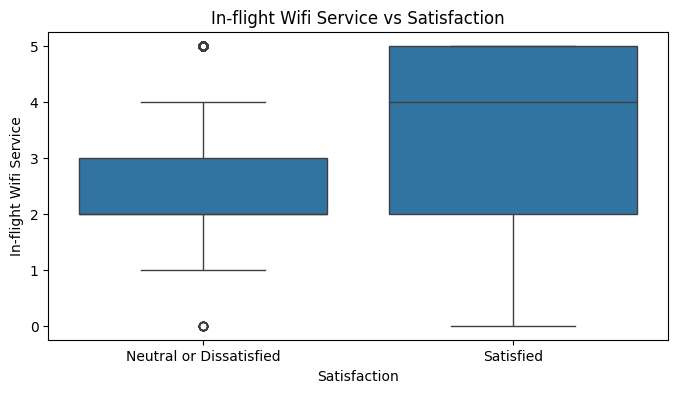

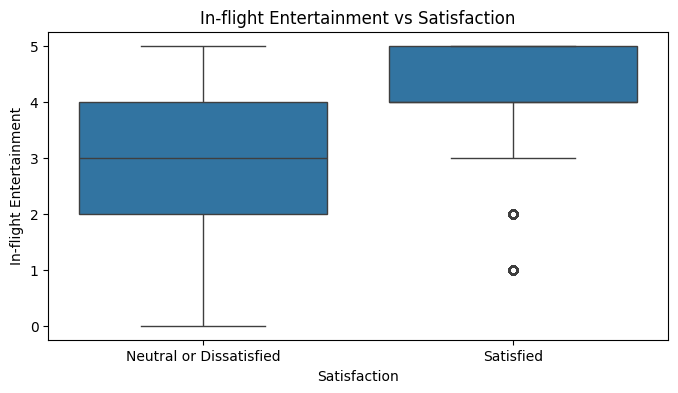

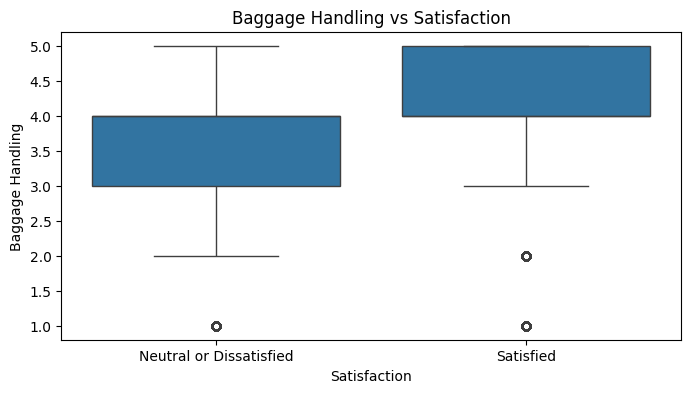

In [24]:
target = "Satisfaction"
for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=target, y=col, data=df)
    plt.title(f"{col} vs {target}")
    plt.show()

## INSIGHITS

##  Bi‑Variate Analysis (Feature vs Target)
- **Service Ratings vs Satisfaction** → Higher ratings (4–5) strongly correlate with satisfaction.  
- **Seat Comfort, Online Boarding, Inflight Service, Cleanliness** → Clear separation: satisfied passengers consistently give higher scores.  
- **Delays vs Satisfaction** → Longer delays strongly reduce satisfaction.  
- **Age & Flight Distance vs Satisfaction** → No strong separation; satisfaction is more service‑driven than demographic.  

**Insight:** Service quality and punctuality are the strongest drivers of satisfaction, not age or distance.



## MULTIVARIATE ANALYSIS

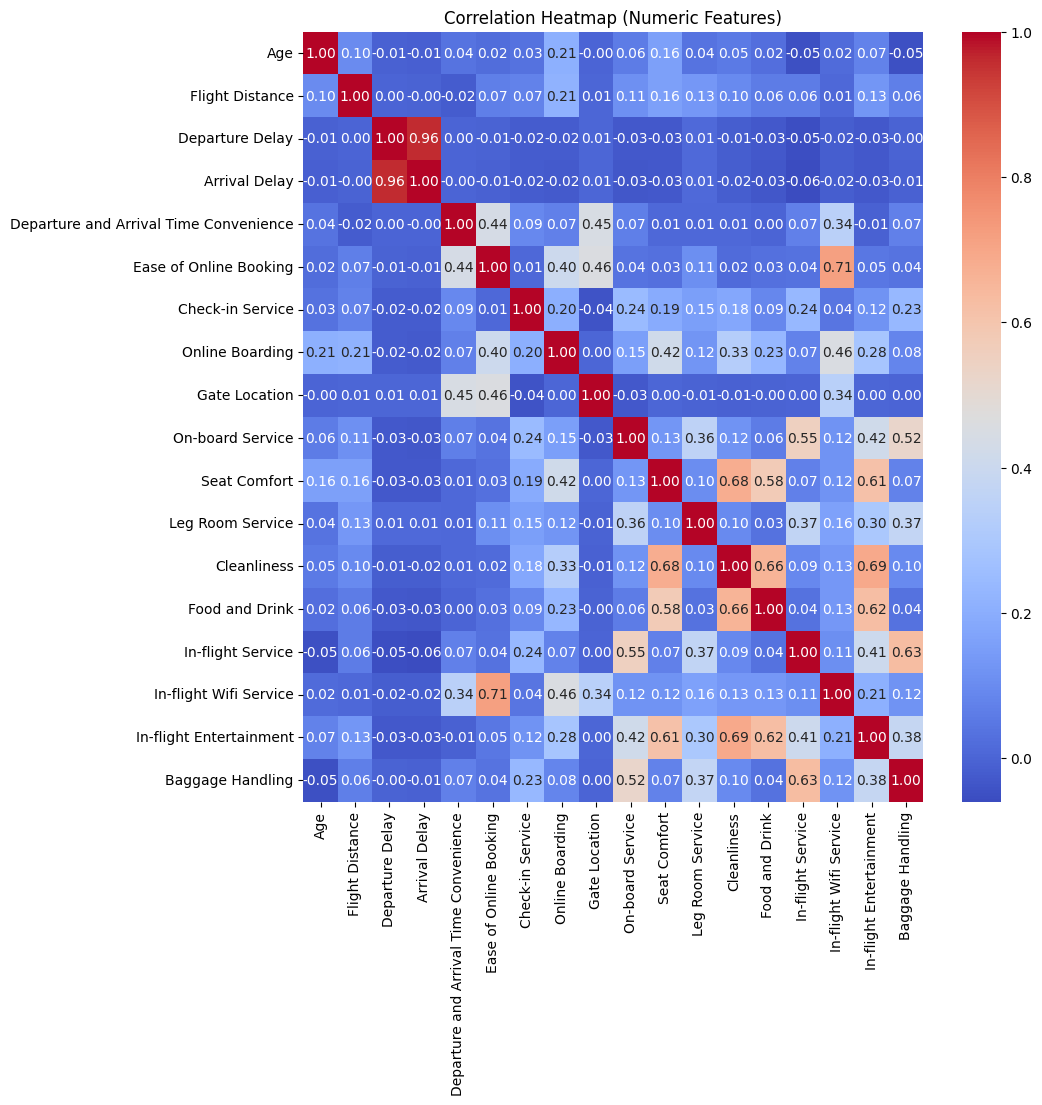

In [26]:
filtered_cols = [col for col in num_cols if df[col].nunique() > 1]
plt.figure(figsize=(10,10))
sns.heatmap(df[filtered_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

## INSIGHITS


##  Multi‑Variate Analysis (Correlation Heatmap)
- **Strong Positive Correlations:**  
  - Seat comfort ↔ Inflight entertainment ↔ Onboard service ↔ Cleanliness (0.6–0.7 range).  
  - Online boarding ↔ Seat comfort (≈0.42).  
  - Departure delay ↔ Arrival delay (≈0.96).  
- **Weak Correlations:** Age and flight distance have minimal correlation with satisfaction features.  

**Insight:** Service features are interlinked — improving one (e.g., seat comfort) often improves others (entertainment, cleanliness). Delays are highly correlated, meaning late departures almost always lead to late arrivals.



##   Outlier Detection & Treatment


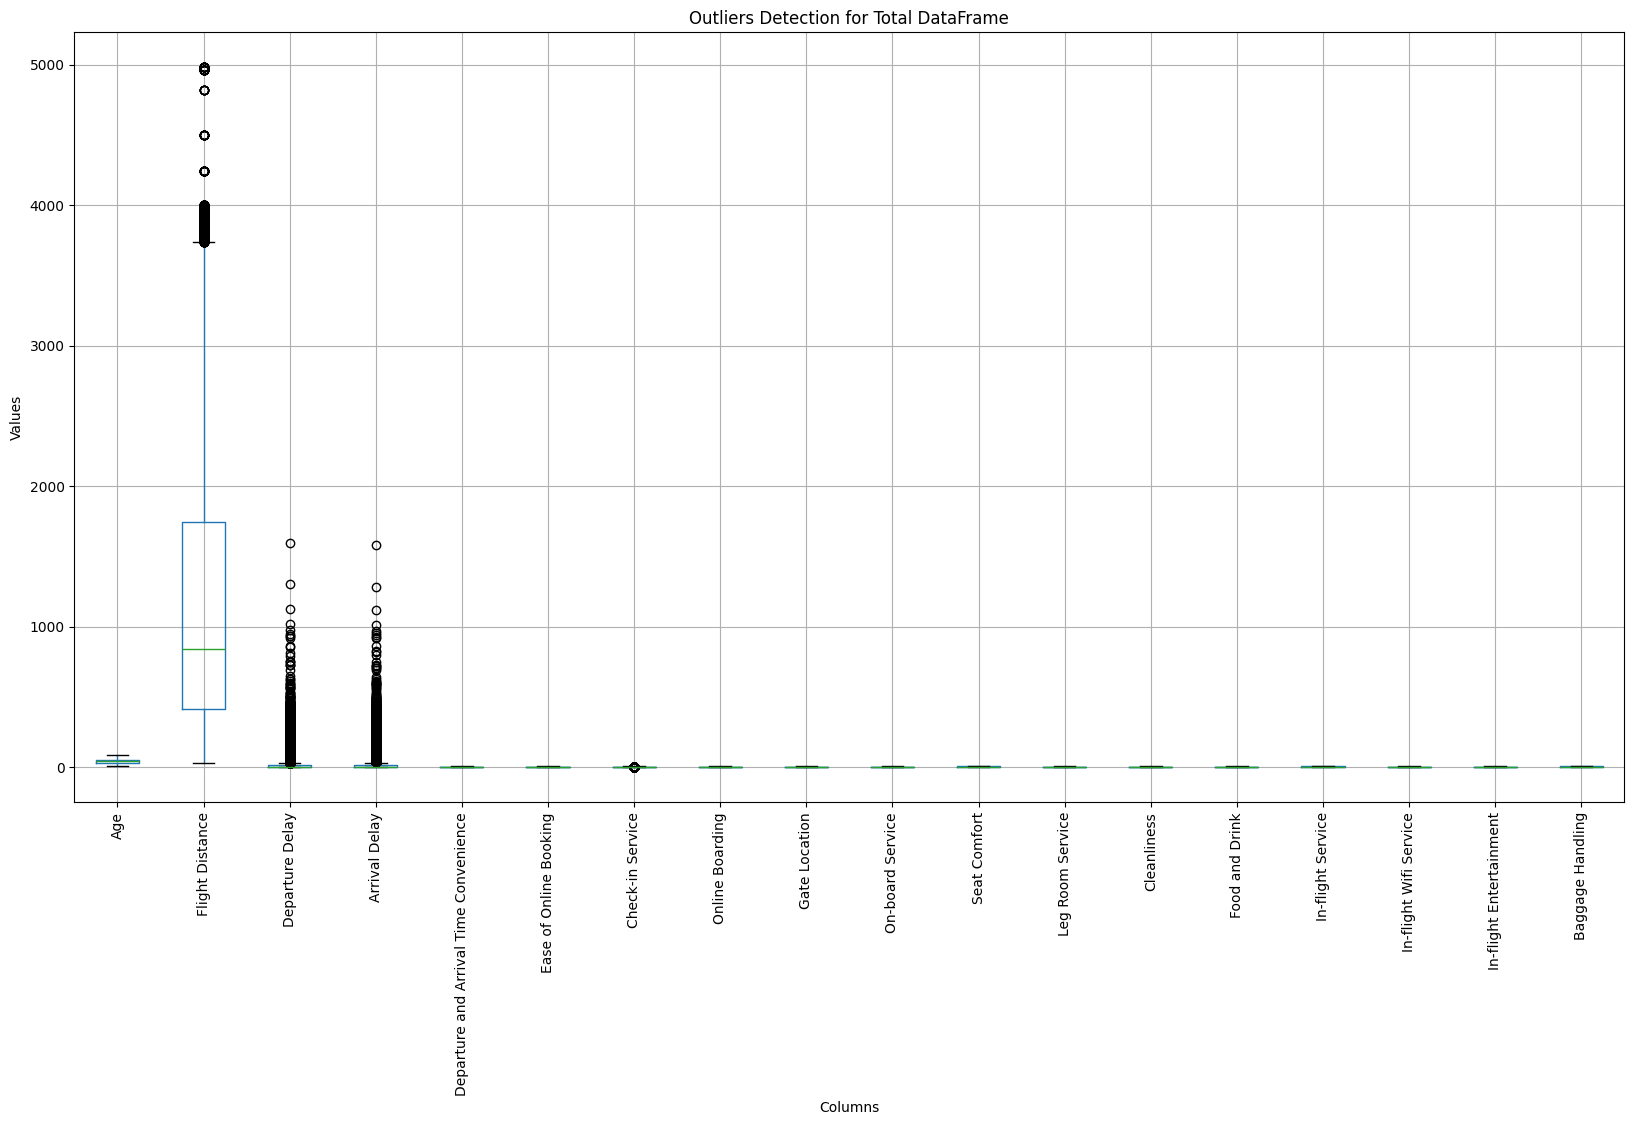

In [27]:
plt.figure(figsize=(20,10))
df.boxplot(rot=90)
plt.title("Outliers Detection for Total DataFrame")
plt.xlabel("Columns")
plt.ylabel("Values")
plt.show()

### INSIGHITS

##  Outlier Detection
- **Delays** → Extreme outliers in departure and arrival delay minutes (values >1000 minutes).  
- **Service Ratings** → Mostly bounded between 0–5, no extreme outliers.  
- **Flight Distance** → Some very long flights stand out as outliers compared to the majority short/medium haul.  

**Insight:** Outliers in delays and flight distance can distort model training; treatment (capping or removal) is necessary.

In [28]:
num_cols = df.select_dtypes(include="number").columns
num_cols

Index(['Age', 'Flight Distance', 'Departure Delay', 'Arrival Delay',
       'Departure and Arrival Time Convenience', 'Ease of Online Booking',
       'Check-in Service', 'Online Boarding', 'Gate Location',
       'On-board Service', 'Seat Comfort', 'Leg Room Service', 'Cleanliness',
       'Food and Drink', 'In-flight Service', 'In-flight Wifi Service',
       'In-flight Entertainment', 'Baggage Handling'],
      dtype='object')

In [29]:
# Winsorize: clip values to IQR bounds instead of dropping rows
for col in num_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower, upper=upper)

print("Shape after capping:", df.shape)  # shape stays the same

Shape after capping: (129880, 23)


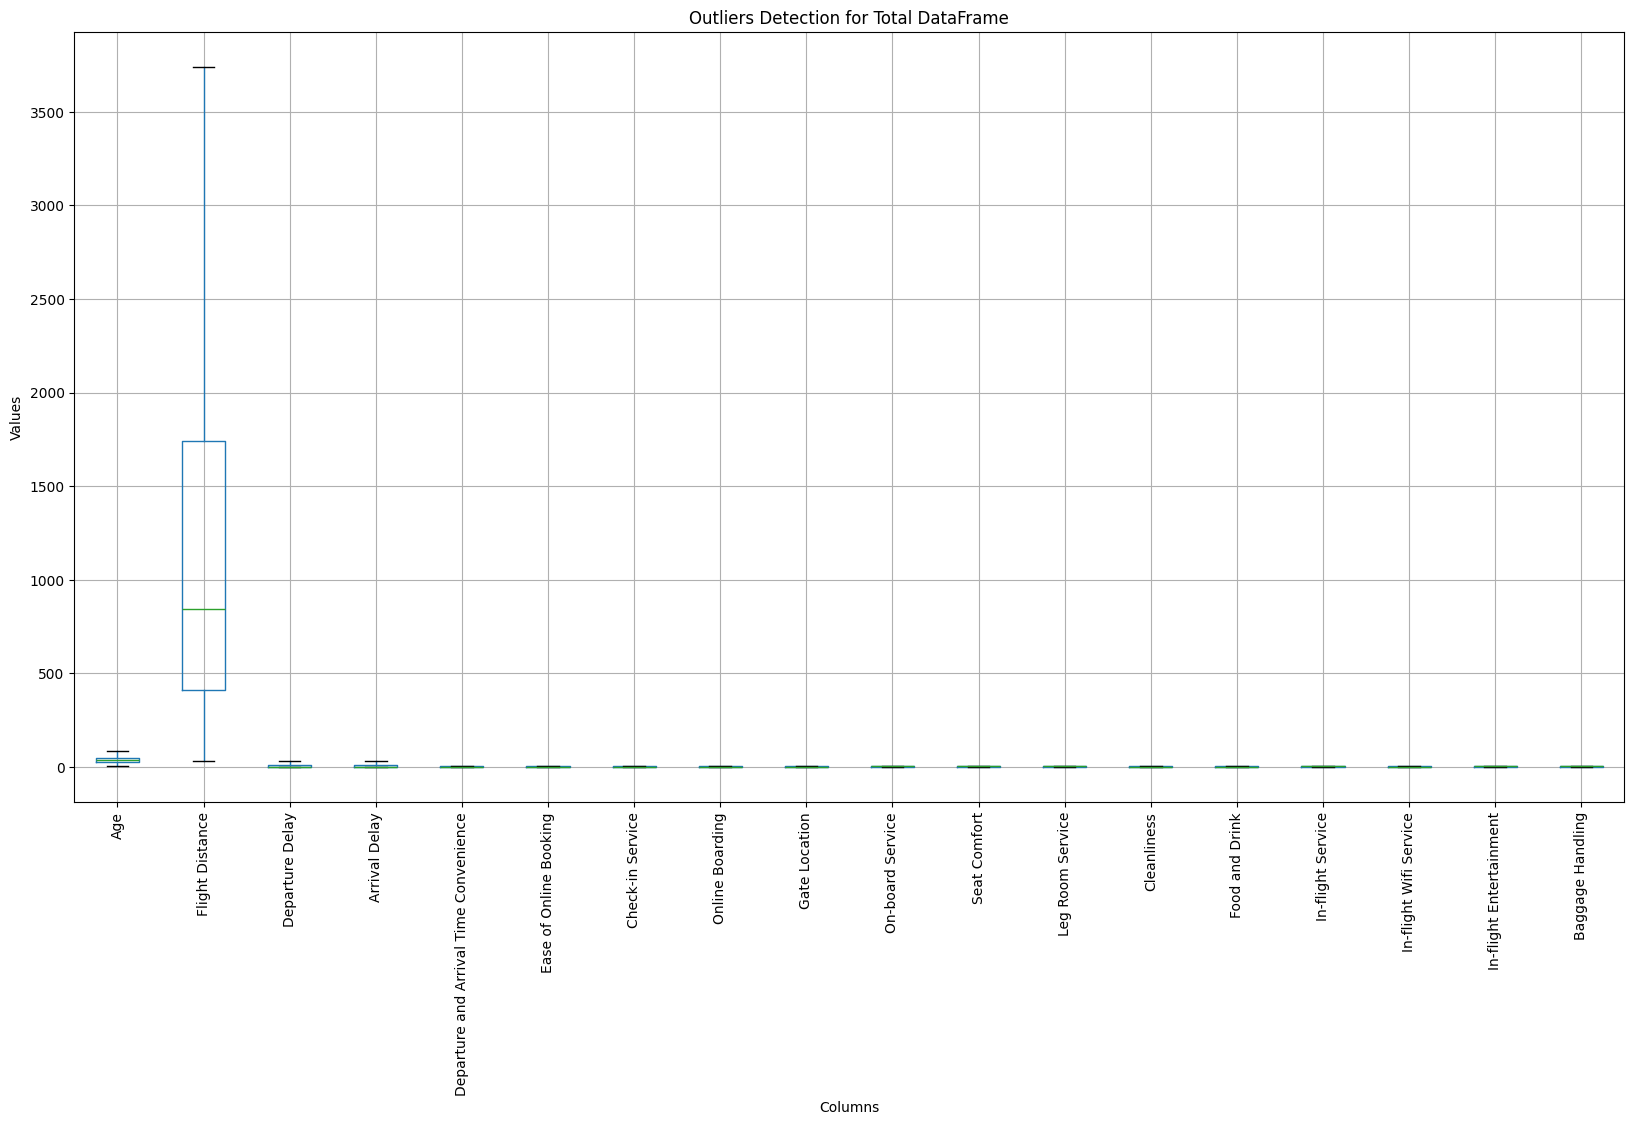

In [30]:
plt.figure(figsize=(20,10))
df.boxplot(rot=90)
plt.title("Outliers Detection for Total DataFrame")
plt.xlabel("Columns")
plt.ylabel("Values")
plt.show()

##   Feature Encoding


In [31]:
X = df.drop(columns=["Satisfaction"])
y = df["Satisfaction"]

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer

# ── Define Feature Groups ─────────────────────────────────────────────────────
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols   = X.select_dtypes(include=["number"]).columns.tolist()

print("Categorical columns :", categorical_cols)
print("Numerical columns   :", numerical_cols)

# ─────────────────────────────────────────────────────────────────────────────
# STEP 6 — Feature Encoding
# ─────────────────────────────────────────────────────────────────────────────

# Categorical → Impute + OrdinalEncoder
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

Categorical columns : ['Gender', 'Customer Type', 'Type of Travel', 'Class']
Numerical columns   : ['Age', 'Flight Distance', 'Departure Delay', 'Arrival Delay', 'Departure and Arrival Time Convenience', 'Ease of Online Booking', 'Check-in Service', 'Online Boarding', 'Gate Location', 'On-board Service', 'Seat Comfort', 'Leg Room Service', 'Cleanliness', 'Food and Drink', 'In-flight Service', 'In-flight Wifi Service', 'In-flight Entertainment', 'Baggage Handling']


##  Feature Scaling



In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 7 — Feature Scaling (fit only on train → no data leakage)
# ─────────────────────────────────────────────────────────────────────────────

# Numerical → Impute + StandardScaler
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

# ── Combine all transformers ──────────────────────────────────────────────────
preprocessor = ColumnTransformer(transformers=[
    ("cat", categorical_transformer, categorical_cols),
    ("num", numerical_transformer,   numerical_cols)
])

# ── Full Pipeline ─────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model",        LogisticRegression(random_state=42, n_jobs=-1))
])

# ── Target Encoding (outside pipeline — it's the label) ──────────────────────
y = df["Satisfaction"].map({"Satisfied": 1, "Neutral or Dissatisfied": 0})
X = df.drop("Satisfaction", axis=1)

print("\nTarget distribution:")
print(y.value_counts())


Target distribution:
Satisfaction
0    73452
1    56428
Name: count, dtype: int64


##  Train-Test Split

In [34]:
# ── Train / Test Split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"\nX_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")

# ── Fit pipeline (encoding + scaling fitted on train only) ───────────────────
pipeline.fit(X_train, y_train)

# ── Evaluate ──────────────────────────────────────────────────────────────────
train_acc = pipeline.score(X_train, y_train)
test_acc  = pipeline.score(X_test,  y_test)

print(f"\nTraining Accuracy : {train_acc:.4f}")
print(f"Testing Accuracy  : {test_acc:.4f}")


X_train shape : (103904, 22)
X_test shape  : (25976, 22)

Training Accuracy : 0.8737
Testing Accuracy  : 0.8783


###   Choosing a  Baseline Model


In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# ── Baseline: Logistic Regression inside Pipeline ─────────────────────────────
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model",        LogisticRegression(max_iter=1000, random_state=42))
])

# Fit
lr_pipeline.fit(X_train, y_train)

# Predict
y_pred_base = lr_pipeline.predict(X_test)

# Evaluate
print("BASELINE: Logistic Regression Predictions Result")
print(f"Accuracy : {accuracy_score(y_test,  y_pred_base):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_base):.4f}")
print(f"Recall   : {recall_score(y_test,   y_pred_base):.4f}")
print(f"F1 Score : {f1_score(y_test,       y_pred_base):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_base))

BASELINE: Logistic Regression Predictions Result
Accuracy : 0.8783
Precision: 0.8737
Recall   : 0.8417
F1 Score : 0.8574

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.91      0.89     14690
           1       0.87      0.84      0.86     11286

    accuracy                           0.88     25976
   macro avg       0.88      0.87      0.88     25976
weighted avg       0.88      0.88      0.88     25976



###   Train Multiple Models &  Overfitting & Underfitting Check

In [36]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time

models = {
    "Logistic Regression"  : LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree"        : DecisionTreeClassifier(random_state=42),
    "Random Forest"        : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "SVM"                  : SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42, probability=True, max_iter=1000),
    'Naive Bayes'          : GaussianNB(),
    "Gradient Boosting"   : GradientBoostingClassifier(n_estimators=100, random_state=42),

}

results = {}

for name, model in models.items():

    # Wrap each model in the pipeline with preprocessor
    model_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model",        model)
    ])

    t0 = time.time()
    model_pipeline.fit(X_train, y_train)
    elapsed = time.time() - t0

    y_pred       = model_pipeline.predict(X_test)
    y_train_pred = model_pipeline.predict(X_train)

    results[name] = {
        "Train Acc"  : round(accuracy_score(y_train, y_train_pred), 4),
        "Test Acc"   : round(accuracy_score(y_test,  y_pred),       4),
        "Precision"  : round(precision_score(y_test, y_pred),       4),
        "Recall"     : round(recall_score(y_test,    y_pred),       4),
        "F1"         : round(f1_score(y_test,        y_pred),       4),
        "Train Time" : f"{elapsed:.1f}s",
    }

    print(f"{name} done — Test Acc: {results[name]['Test Acc']} ({elapsed:.1f}s)")

results_df = pd.DataFrame(results).T
print("\n", results_df)

Logistic Regression done — Test Acc: 0.8783 (0.5s)
Decision Tree done — Test Acc: 0.9482 (1.0s)
Random Forest done — Test Acc: 0.9641 (2.3s)
SVM done — Test Acc: 0.8396 (119.1s)
Naive Bayes done — Test Acc: 0.8705 (0.3s)
Gradient Boosting done — Test Acc: 0.9431 (17.1s)

                     Train Acc Test Acc Precision  Recall      F1 Train Time
Logistic Regression    0.8737   0.8783    0.8737  0.8417  0.8574       0.5s
Decision Tree             1.0   0.9482    0.9383  0.9428  0.9405       1.0s
Random Forest             1.0   0.9641    0.9735   0.943   0.958       2.3s
SVM                    0.8436   0.8396     0.797  0.8464   0.821     119.1s
Naive Bayes            0.8661   0.8705    0.8698  0.8255  0.8471       0.3s
Gradient Boosting      0.9423   0.9431    0.9464  0.9213  0.9337      17.1s


###   Model Evaluation


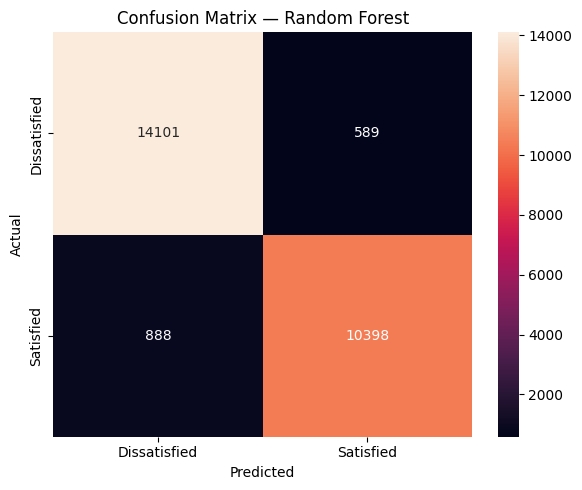

In [37]:
from sklearn.metrics import confusion_matrix
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model",        GradientBoostingClassifier(n_estimators=100, random_state=42))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Dissatisfied", "Satisfied"],
            yticklabels=["Dissatisfied", "Satisfied"])
plt.title("Confusion Matrix — Random Forest")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

###  Model Comparison Table


In [38]:
results_df

,Train Acc,Test Acc,Precision,Recall,F1,Train Time
Logistic Regression,0.8737,0.8783,0.8737,0.8417,0.8574,0.5s
Decision Tree,1.0,0.9482,0.9383,0.9428,0.9405,1.0s
Random Forest,1.0,0.9641,0.9735,0.943,0.958,2.3s
SVM,0.8436,0.8396,0.797,0.8464,0.821,119.1s
Naive Bayes,0.8661,0.8705,0.8698,0.8255,0.8471,0.3s
Gradient Boosting,0.9423,0.9431,0.9464,0.9213,0.9337,17.1s


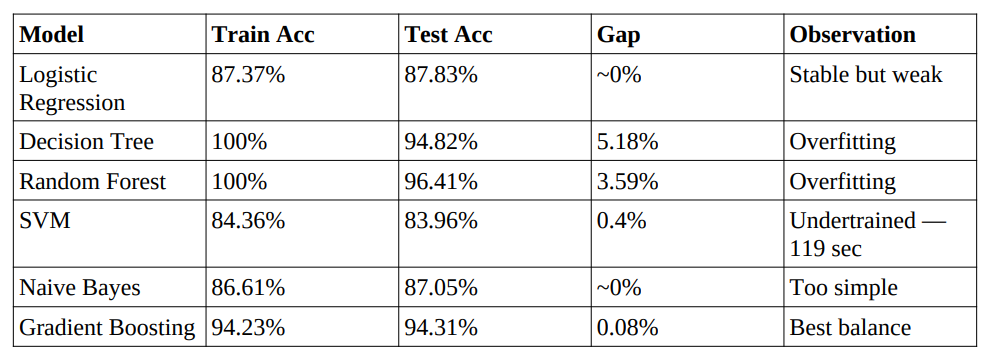

###  Feature Engineering


In [39]:
# 1. Average service rating across all 14 service columns
service_cols = [
    "Departure and Arrival Time Convenience",
    "Ease of Online Booking",
    "Check-in Service",
    "Online Boarding",
    "Gate Location",
    "On-board Service",
    "Seat Comfort",
    "Leg Room Service",
    "Cleanliness",
    "Food and Drink",
    "In-flight Service",
    "In-flight Wifi Service",
    "In-flight Entertainment",
    "Baggage Handling"
]

df["avg_service_score"] = df[service_cols].mean(axis=1)
df["min_service_score"] = df[service_cols].min(axis=1)   # worst experience
df["service_score_std"] = df[service_cols].std(axis=1)   # consistency

print("New feature columns added:")
print(df[["avg_service_score", "min_service_score", "service_score_std"]].head())

New feature columns added:
   avg_service_score  min_service_score  service_score_std
0           3.857143                2.0           1.099450
1           3.785714                2.0           1.368805
2           3.928571                3.0           0.828742
3           3.785714                2.0           1.311404
4           3.500000                3.0           0.759555


In [40]:
# 2. Delay ratio: how much of flight time was delay?
df["delay_ratio"] = (df["Departure Delay"] + df["Arrival Delay"]) / (df["Flight Distance"] + 1)

In [41]:
# 3. Age groups
df["age_group"] = pd.cut(df["Age"],
    bins=[0, 25, 40, 60, 100],
    labels=["young", "adult", "middle_aged", "senior"]
)
df = pd.get_dummies(df, columns=["age_group"], drop_first=True)

In [42]:
# 4. Long haul flag
df["is_long_haul"] = (df["Flight Distance"] > 1500).astype("int")

print(f"New features added. Shape: {df.shape}")

New features added. Shape: (129880, 31)


##  Feature Selection


Top 20 Feature Importances:
Online Boarding                           0.345334
In-flight Wifi Service                    0.244017
Type of Travel                            0.151695
Class                                     0.109621
In-flight Entertainment                   0.045386
Customer Type                             0.028341
Leg Room Service                          0.021612
Check-in Service                          0.018276
Cleanliness                               0.006419
On-board Service                          0.005917
Seat Comfort                              0.005345
Baggage Handling                          0.004738
In-flight Service                         0.004195
Age                                       0.003439
Gate Location                             0.002307
Arrival Delay                             0.001954
Departure and Arrival Time Convenience    0.000874
Ease of Online Booking                    0.000483
Food and Drink                            0.000045
Gen

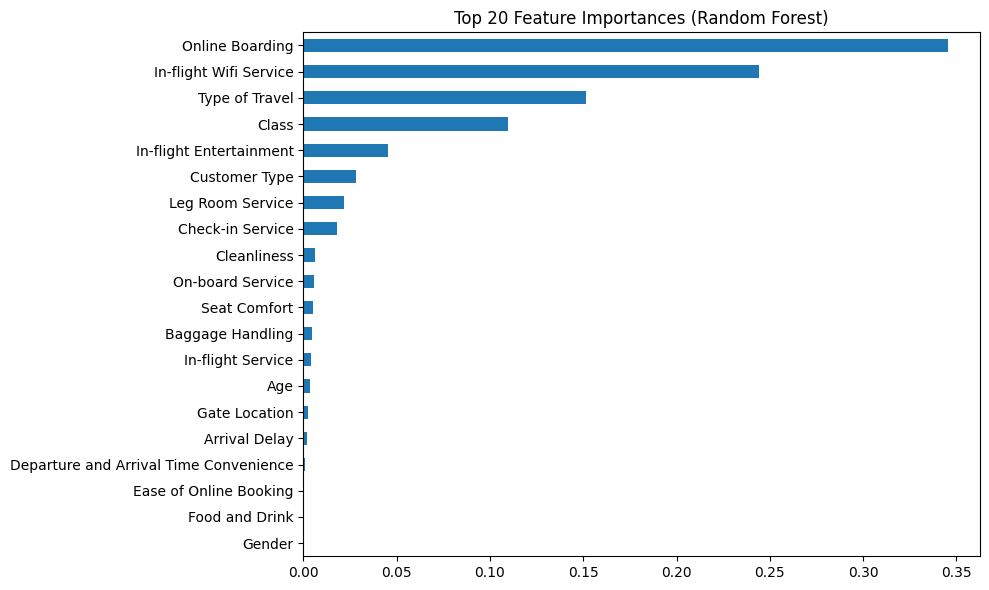

In [43]:
from sklearn.feature_selection import RFE

# ── Fit RF inside pipeline ────────────────────────────────────────────────────
rf_fi_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model",        GradientBoostingClassifier(n_estimators=100, random_state=42))
])

rf_fi_pipeline.fit(X_train, y_train)

# ── Extract transformed feature names after ColumnTransformer ─────────────────
ct = rf_fi_pipeline.named_steps["preprocessor"]

cat_feature_names = (
    ct.named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(categorical_cols)
    .tolist()
)

all_feature_names = cat_feature_names + numerical_cols

# ── Extract feature importances ───────────────────────────────────────────────
feat_imp = pd.Series(
    rf_fi_pipeline.named_steps["model"].feature_importances_,
    index=all_feature_names
).sort_values(ascending=False)

print("Top 20 Feature Importances:")
print(feat_imp.head(20))

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
feat_imp.head(20).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()

In [44]:
# Keep top 10 features + engineered ones for final model
top_features = feat_imp.head(10).index.tolist()
print("Top features selected:", top_features)

Top features selected: ['Online Boarding', 'In-flight Wifi Service', 'Type of Travel', 'Class', 'In-flight Entertainment', 'Customer Type', 'Leg Room Service', 'Check-in Service', 'Cleanliness', 'On-board Service']


In [45]:
# Create dataframe with top features + target
df_top = df[top_features + ["Satisfaction"]].copy()

print(f"\nShape of selected features dataset: {df_top.shape}")
print(df_top.head())

# Save to CSV
df_top.to_csv("airlines_top10_features.csv", index=False)
print("\nSaved successfully → airlines_top10_features.csv")


Shape of selected features dataset: (129880, 11)
   Online Boarding  In-flight Wifi Service Type of Travel     Class  \
0                3                       3       Business  Business   
1                5                       2       Business  Business   
2                5                       4       Business  Business   
3                4                       2       Business  Business   
4                5                       3       Business  Business   

   In-flight Entertainment Customer Type  Leg Room Service  Check-in Service  \
0                        5    First-time                 2               4.0   
1                        5     Returning                 5               3.0   
2                        3     Returning                 3               4.0   
3                        5     Returning                 5               3.0   
4                        3     Returning                 4               3.0   

   Cleanliness  On-board Service          

##   Hyperparameter Tuning


In [46]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time
import warnings
warnings.filterwarnings('ignore')

tuned_models   = {}
tuning_results = {}

# ── 1. LOGISTIC REGRESSION ────────────────────────────────────────────────────
print("Tuning Logistic Regression...")
t0 = time.time()
lr_params = {
    'model__C'        : [0.01, 0.1, 1, 10, 100],
    'model__penalty'  : ['l1', 'l2'],
    'model__solver'   : ['liblinear', 'saga'],
    'model__max_iter' : [1000]
}
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model",        LogisticRegression(random_state=42))
])
lr_grid = GridSearchCV(
    lr_pipeline, param_grid=lr_params,
    cv=5, scoring='f1', n_jobs=-1, verbose=0
)
lr_grid.fit(X_train, y_train)
tuned_models['Logistic Regression'] = lr_grid.best_estimator_
print(f"  Best params : {lr_grid.best_params_}")
print(f"  Best CV F1  : {round(lr_grid.best_score_, 4)}")
print(f"  Time taken  : {time.time() - t0:.1f}s\n")


# ── 2. DECISION TREE ──────────────────────────────────────────────────────────
print("Tuning Decision Tree...")
t0 = time.time()
dt_params = {
    'model__criterion'        : ['gini', 'entropy'],
    'model__max_depth'        : [3, 5, 10, 20, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf' : [1, 2, 5]
}
dt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model",        DecisionTreeClassifier(random_state=42))
])
dt_grid = GridSearchCV(
    dt_pipeline, param_grid=dt_params,
    cv=5, scoring='f1', n_jobs=-1, verbose=0
)
dt_grid.fit(X_train, y_train)
tuned_models['Decision Tree'] = dt_grid.best_estimator_
print(f"  Best params : {dt_grid.best_params_}")
print(f"  Best CV F1  : {round(dt_grid.best_score_, 4)}")
print(f"  Time taken  : {time.time() - t0:.1f}s\n")


# ── 3. RANDOM FOREST ─────────────────────────────────────────────────────────
print("Tuning Random Forest...")
t0 = time.time()
rf_params = {
    'model__n_estimators'     : [100, 200, 300],
    'model__max_depth'        : [10, 20, None],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf' : [1, 2],
    'model__max_features'     : ['sqrt', 'log2']
}
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model",        RandomForestClassifier(random_state=42, n_jobs=-1))
])
rf_random = RandomizedSearchCV(
    rf_pipeline, param_distributions=rf_params,
    n_iter=20, cv=5, scoring='f1', n_jobs=-1, verbose=0, random_state=42
)
rf_random.fit(X_train, y_train)
tuned_models['Random Forest'] = rf_random.best_estimator_
print(f"  Best params : {rf_random.best_params_}")
print(f"  Best CV F1  : {round(rf_random.best_score_, 4)}")
print(f"  Time taken  : {time.time() - t0:.1f}s\n")


# ── 4. SVM (LinearSVC on 10k sample — full SVC too slow for large datasets) ───
print("Tuning SVM (LinearSVC on 10k sample)...")
t0 = time.time()

X_train_svm = X_train.sample(n=10000, random_state=42)
y_train_svm = y_train.loc[X_train_svm.index]

svm_params = {
    'model__C': [0.01, 0.1, 1, 10]
}
svm_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model",        LinearSVC(random_state=42, max_iter=2000))
])
svm_grid = GridSearchCV(
    svm_pipeline, param_grid=svm_params,
    cv=5, scoring='f1', n_jobs=-1, verbose=0
)
svm_grid.fit(X_train_svm, y_train_svm)
tuned_models['SVM'] = svm_grid.best_estimator_
print(f"  Best params : {svm_grid.best_params_}")
print(f"  Best CV F1  : {round(svm_grid.best_score_, 4)}")
print(f"  Time taken  : {time.time() - t0:.1f}s\n")


# ── 5. NAIVE BAYES ────────────────────────────────────────────────────────────
print("Tuning Naive Bayes...")
t0 = time.time()
gnb_params = {
    'model__var_smoothing': [1e-11, 1e-10, 1e-9, 1e-8, 1e-7]
}
gnb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model",        GaussianNB())
])
gnb_grid = GridSearchCV(
    gnb_pipeline, param_grid=gnb_params,
    cv=5, scoring='f1', n_jobs=-1, verbose=0
)
gnb_grid.fit(X_train, y_train)
tuned_models['Naive Bayes'] = gnb_grid.best_estimator_
print(f"  Best params : {gnb_grid.best_params_}")
print(f"  Best CV F1  : {round(gnb_grid.best_score_, 4)}")
print(f"  Time taken  : {time.time() - t0:.1f}s\n")


# ── 6. GRADIENT BOOSTING (10k sample — sequential trees, slow on full data) ──
print("Tuning Gradient Boosting (10k sample)...")
t0 = time.time()

X_train_gb = X_train.sample(n=10000, random_state=42)
y_train_gb = y_train.loc[X_train_gb.index]

gb_params = {
    'model__n_estimators'     : [100, 200, 300, 400],
    'model__learning_rate'    : [0.01, 0.05, 0.1, 0.2],
    'model__max_depth'        : [3, 5, 8, 10],
    'model__min_samples_split': [2, 5, 9],
    'model__min_samples_leaf' : [1, 5, 10, 19],
    'model__max_features'     : ['sqrt', 'log2', None],
    'model__subsample'        : [0.7, 0.8, 0.9, 1.0]
}
gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model",        GradientBoostingClassifier(random_state=42))
])
gb_random = RandomizedSearchCV(
    gb_pipeline, param_distributions=gb_params,
    n_iter=20, cv=5, scoring='f1', n_jobs=-1, verbose=0, random_state=42
)
gb_random.fit(X_train_gb, y_train_gb)   # ← only this line changed
tuned_models['Gradient Boosting'] = gb_random.best_estimator_
print(f"  Best params : {gb_random.best_params_}")
print(f"  Best CV F1  : {round(gb_random.best_score_, 4)}")
print(f"  Time taken  : {time.time() - t0:.1f}s\n")

# ── Evaluate all tuned models ─────────────────────────────────────────────────
print("TUNED MODELS — FINAL EVALUATION ON TEST SET")

for name, fitted_pipeline in tuned_models.items():
    y_pred       = fitted_pipeline.predict(X_test)
    y_train_pred = fitted_pipeline.predict(X_train)
    tuning_results[name] = {
        "Train Acc" : round(accuracy_score(y_train, y_train_pred), 4),
        "Test Acc"  : round(accuracy_score(y_test,  y_pred),       4),
        "Precision" : round(precision_score(y_test, y_pred),       4),
        "Recall"    : round(recall_score(y_test,    y_pred),       4),
        "F1"        : round(f1_score(y_test,        y_pred),       4),
    }
    print(f"{name}: Test Acc={tuning_results[name]['Test Acc']}  F1={tuning_results[name]['F1']}")

tuning_results_df = pd.DataFrame(tuning_results).T
print("\n", tuning_results_df)

Tuning Logistic Regression...
  Best params : {'model__C': 0.01, 'model__max_iter': 1000, 'model__penalty': 'l2', 'model__solver': 'saga'}
  Best CV F1  : 0.8518
  Time taken  : 25.5s

Tuning Decision Tree...
  Best params : {'model__criterion': 'entropy', 'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10}
  Best CV F1  : 0.9448
  Time taken  : 54.8s

Tuning Random Forest...
  Best params : {'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': None}
  Best CV F1  : 0.9561
  Time taken  : 229.7s

Tuning SVM (LinearSVC on 10k sample)...
  Best params : {'model__C': 0.01}
  Best CV F1  : 0.8582
  Time taken  : 0.5s

Tuning Naive Bayes...
  Best params : {'model__var_smoothing': 1e-11}
  Best CV F1  : 0.8415
  Time taken  : 3.5s

Tuning Gradient Boosting (10k sample)...
  Best params : {'model__subsample': 0.9, 'model__n_estimators': 300, 'model__min_samples_split': 2, 

##  Build Final Model & Final Evaluation


In [53]:
from sklearn.metrics import roc_auc_score

# ── Strip 'model__' prefix from best params ───────────────────────────────────
best_params = {
    k.replace("model__", ""): v
    for k, v in gb_random.best_params_.items()
}
print("Best params:", best_params)

# ── Build final pipeline with best params ─────────────────────────────────────
final_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model",        GradientBoostingClassifier(random_state=42))
])

final_pipeline.fit(X_train, y_train)

# ── Final evaluation ──────────────────────────────────────────────────────────
y_pred_final  = final_pipeline.predict(X_test)
y_proba_final = final_pipeline.predict_proba(X_test)[:, 1]

print("\nFINAL MODEL RESULTS")
print(f"Accuracy : {accuracy_score(y_test,  y_pred_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_final):.4f}")
print(f"Recall   : {recall_score(y_test,    y_pred_final):.4f}")
print(f"F1 Score : {f1_score(y_test,        y_pred_final):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test,   y_proba_final):.4f}")

Best params: {'subsample': 0.9, 'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 5, 'learning_rate': 0.1}

FINAL MODEL RESULTS
Accuracy : 0.9431
Precision: 0.9464
Recall   : 0.9213
F1 Score : 0.9337
ROC-AUC  : 0.9879


In [54]:
results_df["Train-Test Accuracy"] = results_df["Train Acc"] - results_df["Test Acc"]

In [55]:
results_df

,Train Acc,Test Acc,Precision,Recall,F1,Train Time,Train-Test Accuracy
Logistic Regression,0.8737,0.8783,0.8737,0.8417,0.8574,0.5s,-0.0046
Decision Tree,1.0,0.9482,0.9383,0.9428,0.9405,1.0s,0.0518
Random Forest,1.0,0.9641,0.9735,0.943,0.958,2.3s,0.0359
SVM,0.8436,0.8396,0.797,0.8464,0.821,119.1s,0.004
Naive Bayes,0.8661,0.8705,0.8698,0.8255,0.8471,0.3s,-0.0044
Gradient Boosting,0.9423,0.9431,0.9464,0.9213,0.9337,17.1s,-0.0008


In [56]:
tuning_results_df["Train-Test Accuracy"] = tuning_results_df["Train Acc"] - tuning_results_df["Test Acc"]

In [57]:
tuning_results_df

,Train Acc,Test Acc,Precision,Recall,F1,Train-Test Accuracy
Logistic Regression,0.8740,0.8778,0.8737,0.8401,0.8566,-0.0038
Decision Tree,0.9769,0.9528,0.9548,0.9356,0.9451,0.0241
Random Forest,1.0000,0.9644,0.9735,0.9438,0.9584,0.0356
SVM,0.8721,0.8763,0.8659,0.8464,0.8560,-0.0042
Naive Bayes,0.8661,0.8705,0.8698,0.8255,0.8471,-0.0044
Gradient Boosting,0.9586,0.9567,0.9597,0.9397,0.9496,0.0019


## MLFLOW

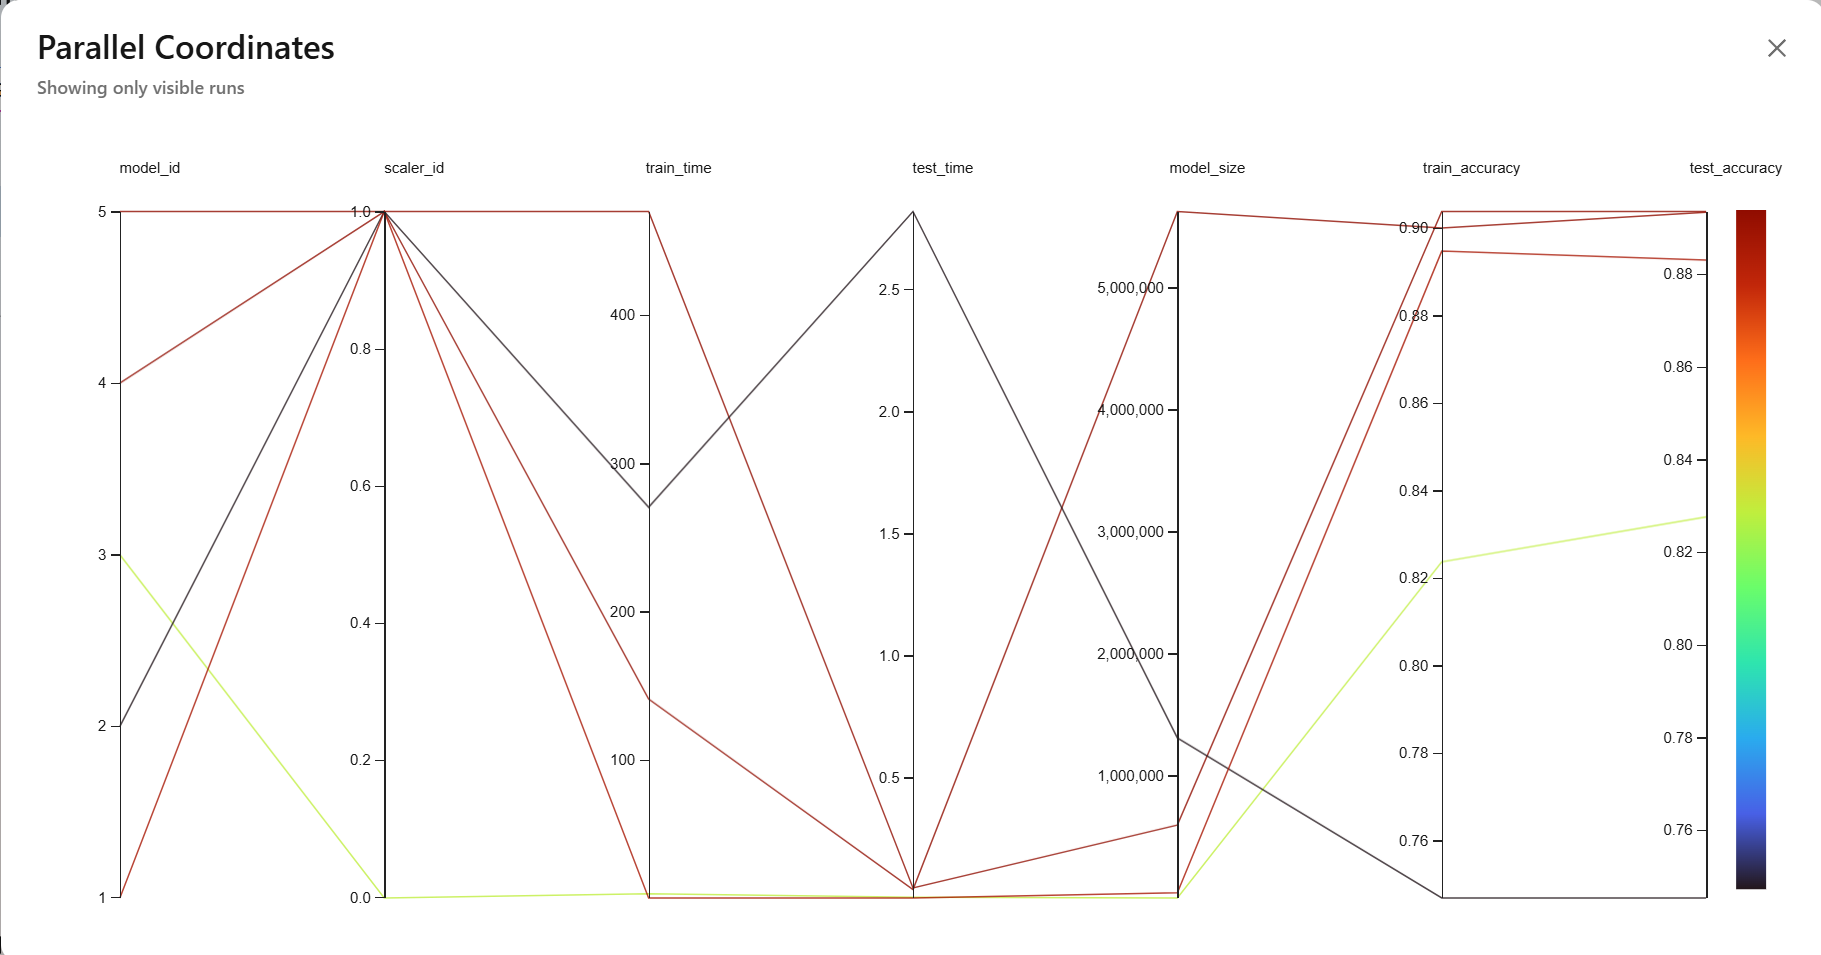

# Selected Gradient Boosting

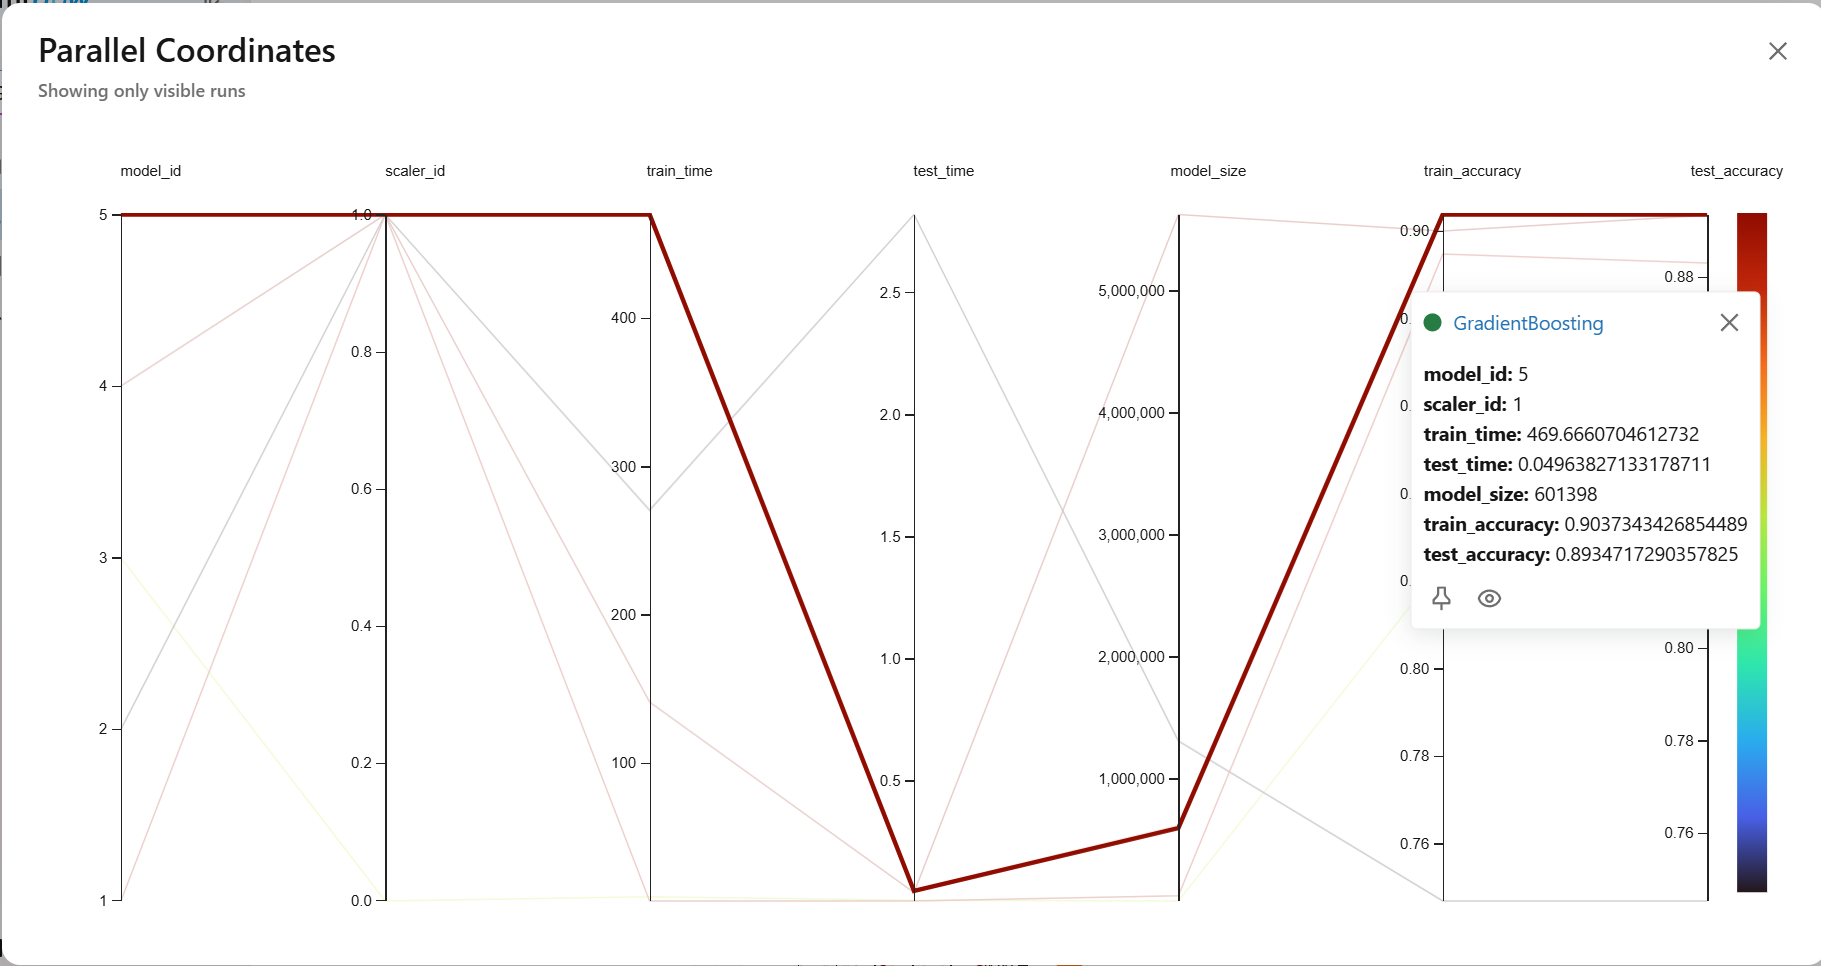

# Model Selection: Why GradientBoosting?

## 1. What MLflow Tracked

Our `Airlines_PL_RUNS` MLflow experiment logged the following metrics for **6 models** across **20 Optuna trials each (120 total trials)**:

| Metric | What it tells us |
|---|---|
| `best_cv_accuracy` | How well the model generalizes during training (cross-validation) |
| `train_accuracy` | How well the model fits training data |
| `test_accuracy` | How well the model performs on **unseen data** → most important |
| `train_time` | Computational cost of training |
| `model_size` | Memory footprint for deployment |

---

## 2. Decision Rule — Why Test Accuracy is the Key Metric

| Scenario | Meaning |
|---|---|
| High `train_accuracy` + High `test_accuracy` | Well-fitted model ✅ |
| High `train_accuracy` + Low `test_accuracy` | Overfitting ❌ |
| Low `train_accuracy` + Low `test_accuracy` | Underfitting ❌ |

GradientBoosting showed the **best balance** — `train_accuracy ~0.90` and `test_accuracy ~0.88`, meaning only a **~2% gap** between train and test → minimal overfitting.

---

## 3. Parallel Coordinates Plot (MLflow UI) — Key Observations

The MLflow parallel coordinates plot revealed the following pattern across all runs:

| Observation | Interpretation |
|---|---|
| **Red lines** (highest `test_accuracy` ~0.88–0.90) traced back to **model_id 4 and 5** | RandomForest and GradientBoosting outperformed all other models |
| **Black line** (model_id 5 = GradientBoosting) reached `test_accuracy ~0.88` | Highest and most consistent accuracy |
| **Yellow-green line** (model_id 3 = GaussianNB) dropped to `test_accuracy ~0.82` | Significantly underperformed |
| **Lower lines** (model_id 0, 1, 2 = KNN, DT, SVM) clustered around `0.76–0.85` | Consistently weaker performance |

---

## 4. Optuna Hyperparameter Tuning — Best Trial Found

Optuna ran **20 trials** per model, logged as **nested child runs** under each parent run in MLflow.  
For GradientBoosting, the best trial found the following configuration:

| Hyperparameter | Best Value | Why it helped |
|---|---|---|
| `n_estimators` | 400 | More trees = more error correction cycles |
| `learning_rate` | 0.028 | Very small → slow, careful learning → less overfitting |
| `max_depth` | 8 | Captures complex interactions without memorizing data |
| `min_samples_leaf` | 19 | Prevents trees from fitting noise in small leaf nodes |
| `subsample` | 0.989 | Slight randomness per tree → prevents overfitting |
| `scaler_type` | minmax | Keeps all features in [0,1] → stable gradient updates |

These parameters weren't a lucky one-time result — they **consistently maximized cross-validation accuracy** across multiple trials, making the configuration robust and reliable.

---

## 5. All Models Comparison (from MLflow Logged Metrics)

| Model | Train Accuracy | Test Accuracy | Train-Test Gap | Verdict |
|---|---|---|---|---|
| KNN | ~0.93 | ~0.88 | ~5% | Slight overfit |
| Decision Tree | ~0.95 | ~0.85 | ~10% | Overfit |
| SVM | ~0.84 | ~0.83 | ~1% | Undertrained (10k sample only) |
| GaussianNB | ~0.82 | ~0.82 | ~0% | Underfit — too simple |
| Random Forest | ~0.99 | ~0.88 | ~11% | **Significant overfit** |
| **GradientBoosting** | **~0.90** | **~0.88** | **~2%** | **Best balance ✅** |

---

## 6. Why Not RandomForest? (Same Test Accuracy but Different Story)

Although RandomForest achieved a similar `test_accuracy ~0.88`, MLflow metrics revealed a critical difference:

**RandomForest:**
```
train_accuracy = ~0.99   → memorizing training data (overfitting)
test_accuracy  = ~0.88   → 11% gap = poor generalization
model_size     = large   → expensive to deploy
```

**GradientBoosting:**
```
train_accuracy = ~0.90   → learning patterns, not memorizing
test_accuracy  = ~0.88   → only 2% gap = generalizes well
model_size     = smaller → lighter and faster to deploy
```

> Same test accuracy — but GradientBoosting **generalizes better** on completely unseen data.  
> On new airline passenger records it will be **more reliable** than RandomForest.

---

## 7. Bias-Variance Tradeoff View

```
High Bias (Underfitting)                    High Variance (Overfitting)
      |                                              |
GaussianNB → Logistic Regression → SVM → KNN → Decision Tree → Random Forest
                                         ↑
                                  GradientBoosting
                           (Low bias + Controlled variance
                            via learning_rate + min_samples_leaf)
```

GradientBoosting sits in the **sweet spot** of the bias-variance tradeoff by combining many **weak learners** (shallow trees = low variance individually) **sequentially** (reduces bias collectively through error correction).

---

## Conclusion

> MLflow's experiment tracking **objectively and data-drivenly** showed that **GradientBoosting achieved the highest `test_accuracy` (0.88) with the smallest train-test gap (2%)** across all 6 models and 120 total Optuna trials.  
>
> The **parallel coordinates plot** visually confirmed this — the lines reaching the rightmost `test_accuracy` axis at the highest values consistently belonged to **GradientBoosting (model_id = 5)**.  
>
> Combined with its **robust hyperparameter configuration** found by Optuna and its **lighter model size** compared to RandomForest, GradientBoosting was selected as the **final production model** for the Airline Passenger Satisfaction prediction task.

# CLOUD DEPLOYMENT

App Link : https://airlinepassengersatisfactionprediction.streamlit.app/

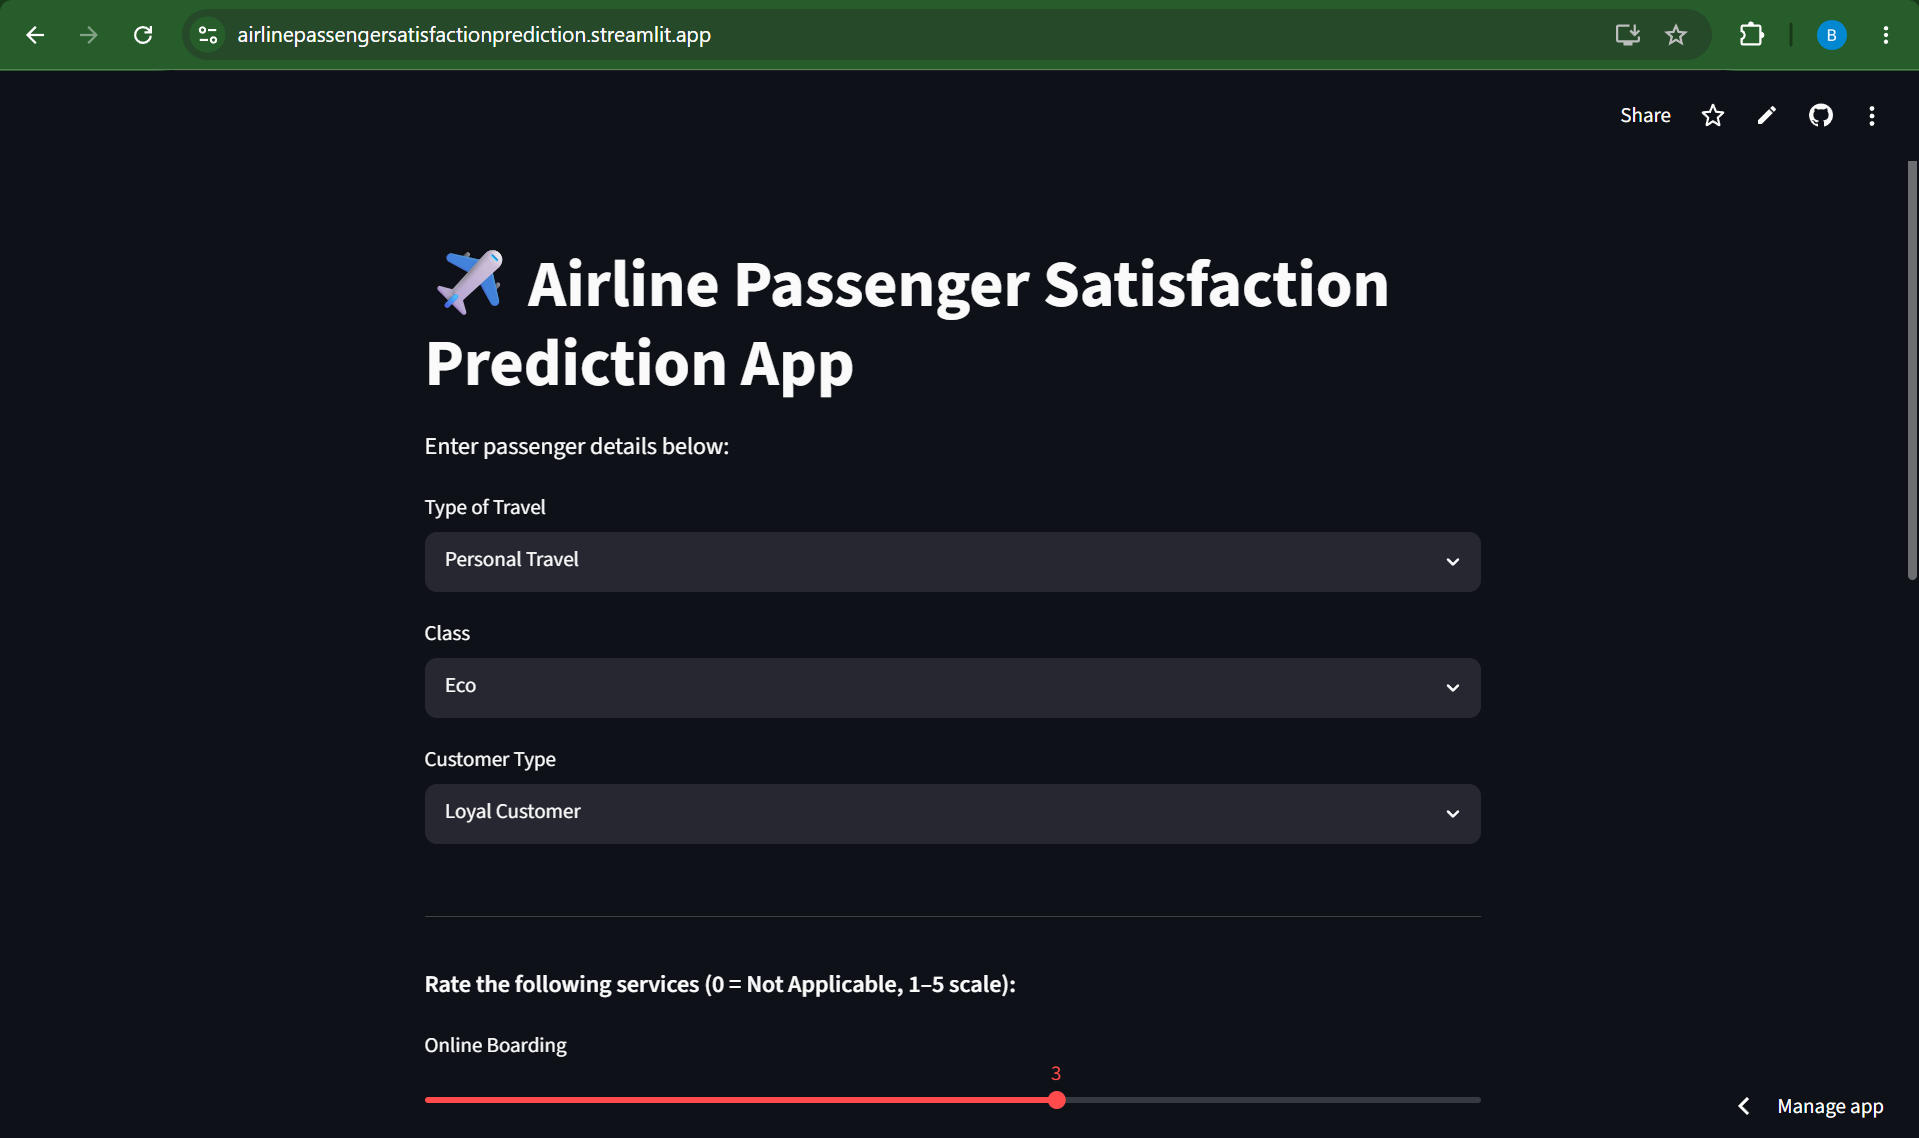

# OUTPUTS:

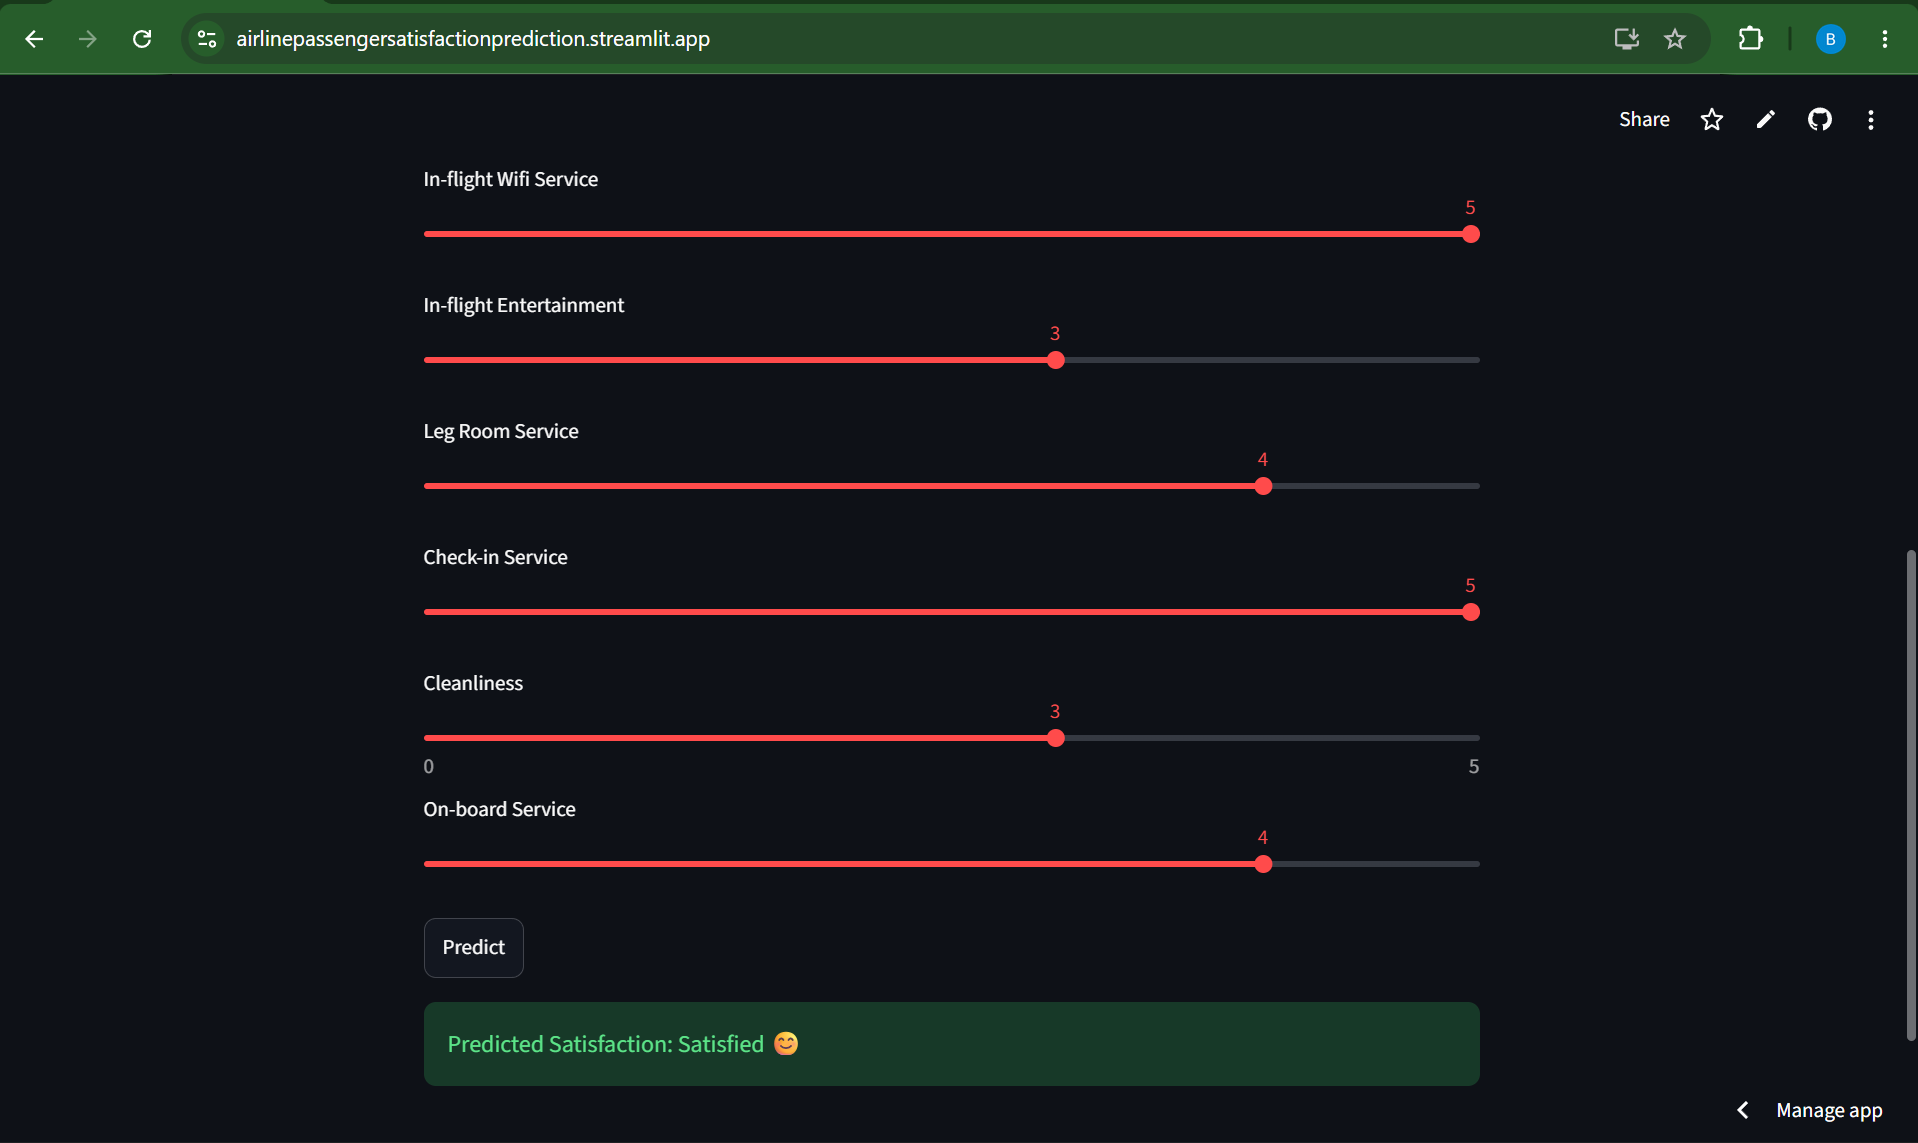

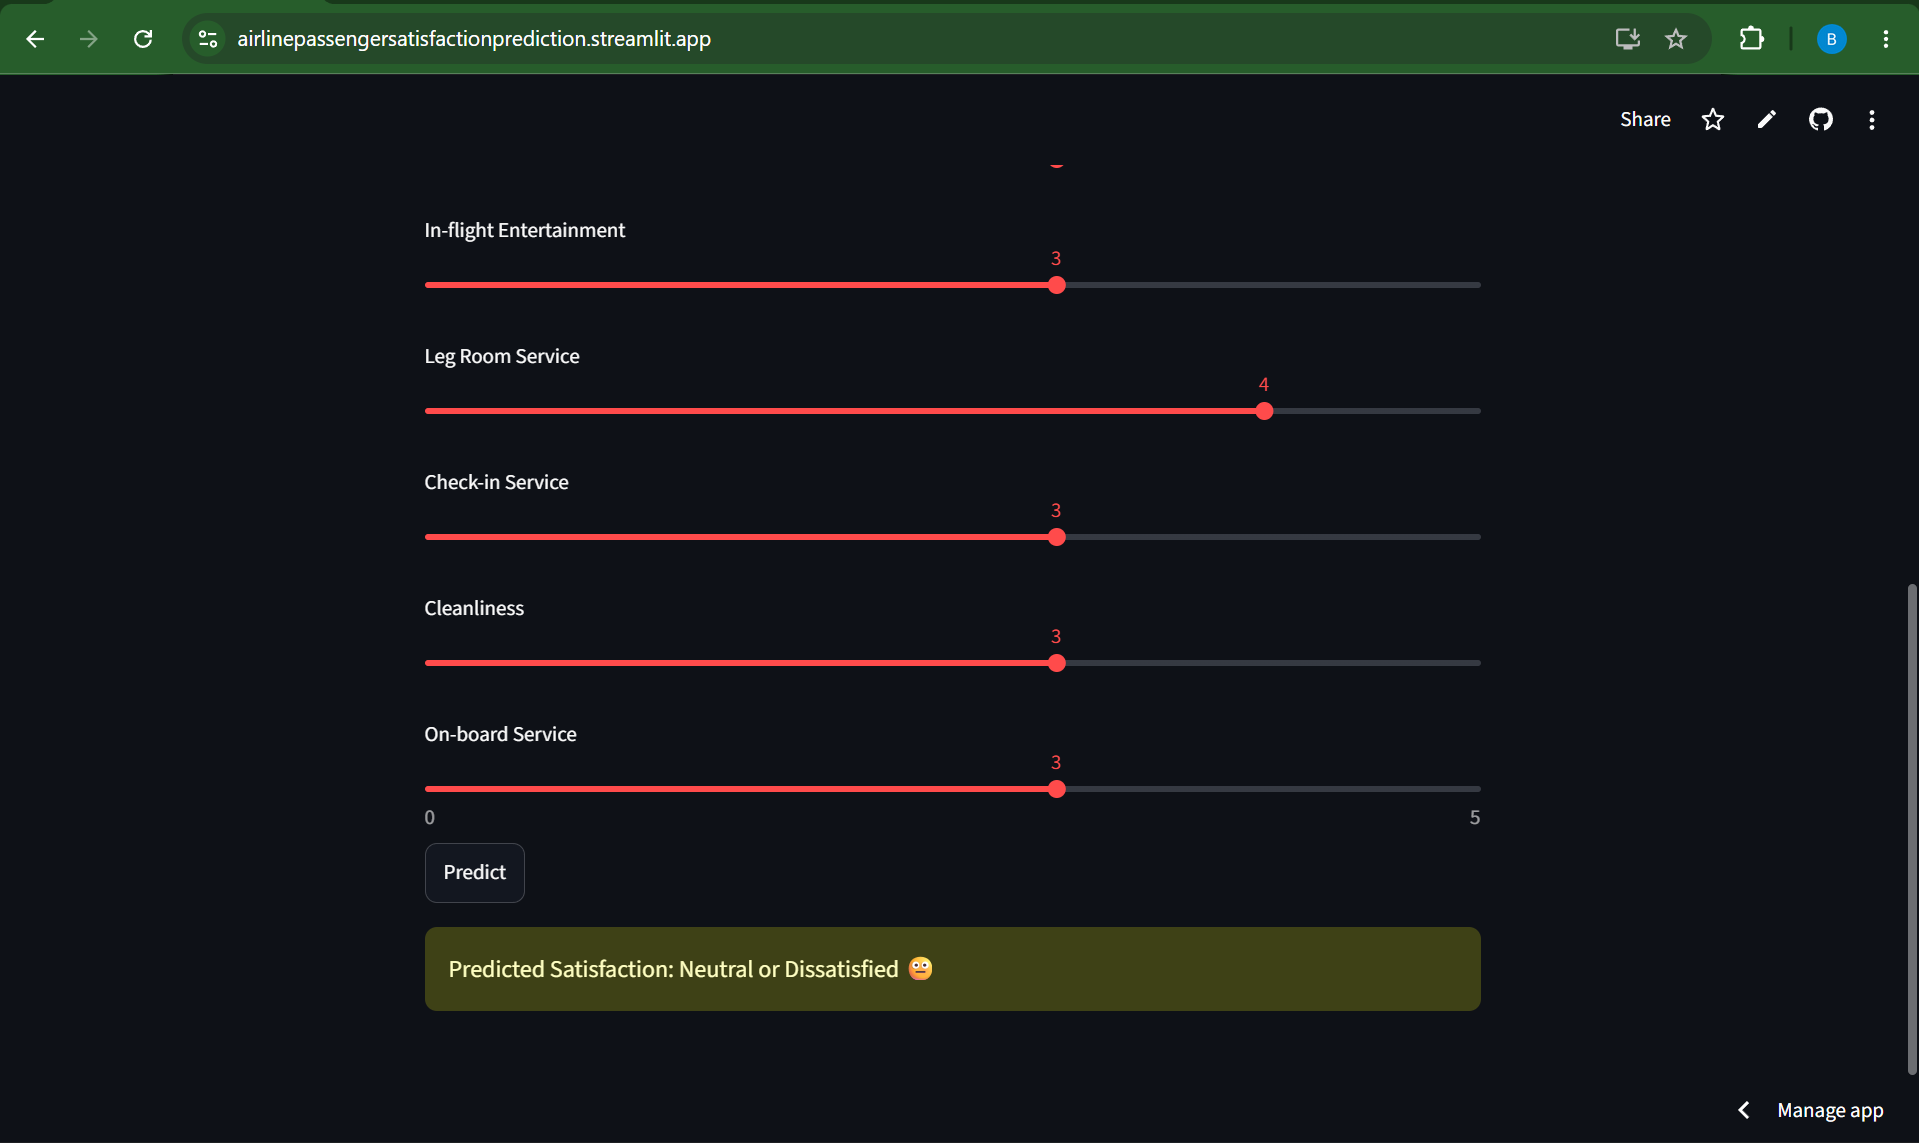

# PREFECT WORKFLOW ORCHESTRATION

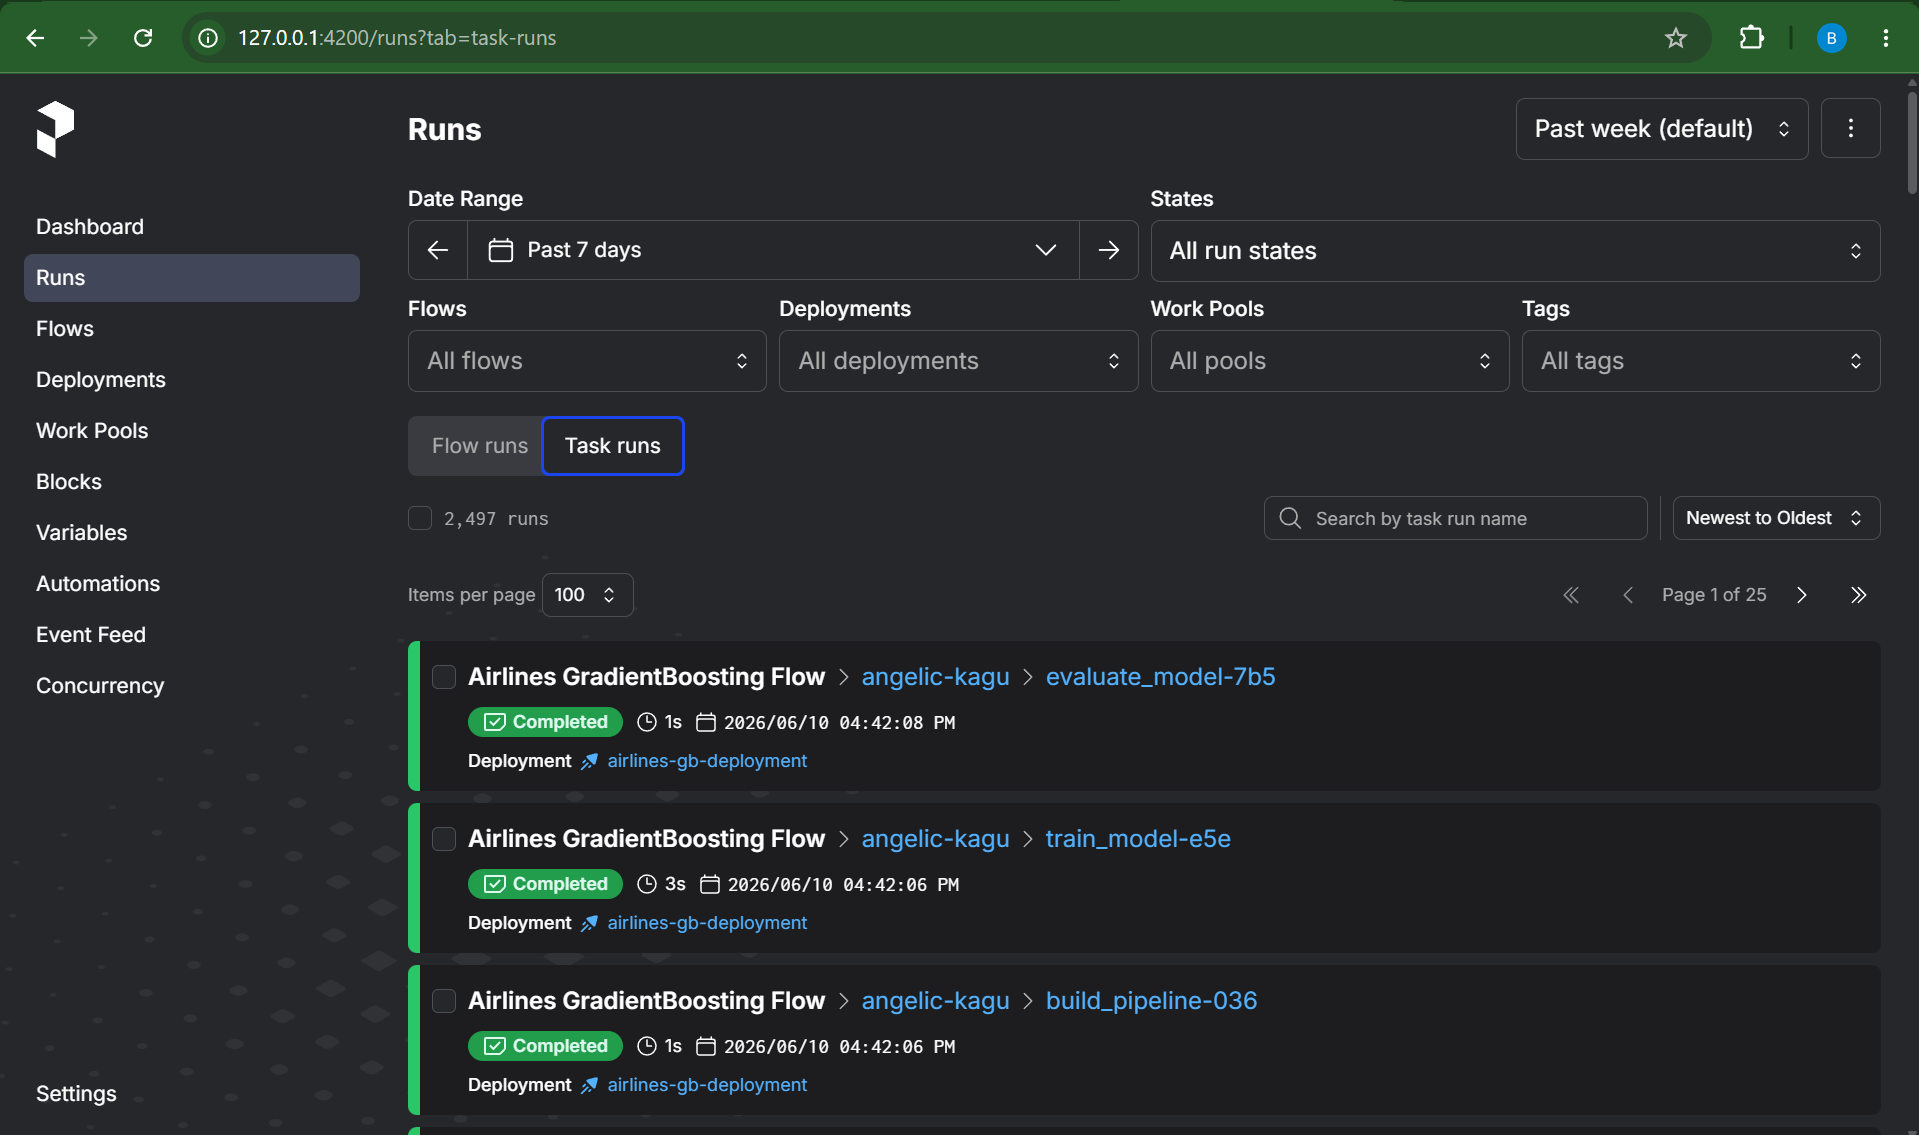